# Free-static target-entropy full-token predicted-`s1` diagnostics

This notebook audits the completed `free_static_target_entropy_full_predicted_s1` run. It is the **run-specific fourth diagnostic notebook** and does not replace the existing no-entropy, target-entropy true-`s1`, or coarse-only notebooks. Those remain the audit record for their own runs.

The controlled change from `free_static_target_entropy` is that the future `s2` classifier is trained using the model's hard predicted `s1` rather than the true future `s1`. The notebook therefore focuses on: the 1- and 5-minute learning trajectory, `s1` quality, native predicted-`s1` fine-token quality, the counterfactual fine-token quality under true `s1`, gradient interaction, decoded candle validity, and whether this run overtakes the coarse-only short-horizon candidate. Prior runs are loaded only for compact controlled comparisons; their detailed diagnostics are not repeated.

Run the cells in order after training completes. Edit paths and diagnostic controls only in **Cell 2**. The notebook writes no files.

In [1]:
# Cell 1 — all imports and repository setup.

from __future__ import annotations

from collections import defaultdict
from pathlib import Path
from typing import Any, Mapping, Sequence

import copy
import json
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from IPython.display import display
from torch import Tensor, nn

# Locate the repository whether Jupyter was launched from the repository
# root or from notebooks/.
_working_directory = Path.cwd().resolve()
_repository_candidates = [
    _working_directory,
    _working_directory.parent,
    _working_directory.parent.parent,
]

REPO_ROOT = next(
    (
        candidate
        for candidate in _repository_candidates
        if (candidate / "src").is_dir()
        and (candidate / "configs").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the dissertation repository root. "
        "Launch Jupyter from the repository root or notebooks/."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

from src.data.cached_token_graph_dataset import CachedTokenGraphDataset
from src.data.load_candle_data import (
    clean_candle_splits,
    get_channel_index,
    load_candle_splits,
)
from src.data.token_graph_dataset import (
    load_origin_aligned_token_cache,
    validate_origin_aligned_token_cache,
)
from src.models.dynamic_graph.model import DynamicGraphTokenForecaster
from src.models.dynamic_graph.modules import aggregate_graph_values
from src.models.kronos_tokenizer import KronosTokenizerAdapter
from src.utils.config import load_yaml


In [2]:
# Cell 2 — paths and diagnostic controls.

INITIAL_TEST_ROOT = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/initial_test"
).expanduser().resolve()

RUN_DIR = (
    INITIAL_TEST_ROOT
    / "free_static_target_entropy_full_predicted_s1"
)

TRUE_S1_REFERENCE_RUN_DIR = (
    INITIAL_TEST_ROOT
    / "free_static_target_entropy"
)

COARSE_REFERENCE_RUN_DIR = (
    INITIAL_TEST_ROOT
    / "free_static_target_entropy_coarse_only"
)

TRAIN_CACHE_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/tokens/"
    "origin_aligned_train_tokens.pt"
).expanduser().resolve()

VALIDATION_CACHE_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/tokens/"
    "origin_aligned_val_tokens.pt"
).expanduser().resolve()

DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "Shared drives/Vishal/data/cached_datasets/"
    "exp-1m-95s-24y/session"
).expanduser().resolve()

FORECASTING_CONFIG_PATH = REPO_ROOT / "configs" / "forecasting.yaml"

BEST_CHECKPOINT_PATH = RUN_DIR / "best_checkpoint.pt"
LAST_CHECKPOINT_PATH = RUN_DIR / "last_checkpoint.pt"
BEST_PREDICTIONS_PATH = RUN_DIR / "best_validation_predictions.pt"
BEST_GRAPHS_PATH = RUN_DIR / "best_validation_graphs.pt"
HISTORY_PATH = RUN_DIR / "history.csv"
METRIC_TABLE_PATH = RUN_DIR / "best_validation_metric_table.csv"
TOKEN_METRIC_PATH = RUN_DIR / "best_validation_token_metrics.csv"
DIAGNOSTICS_PATH = RUN_DIR / "best_validation_diagnostics.json"
RESOLVED_CONFIG_PATH = RUN_DIR / "resolved_config.json"
RUN_METADATA_PATH = RUN_DIR / "run_metadata.json"

REFERENCE_RUN_DIRS = {
    "full_true_s1": TRUE_S1_REFERENCE_RUN_DIR,
    "coarse_only": COARSE_REFERENCE_RUN_DIR,
}

# Detailed model diagnostics use the epoch with the lowest mean h=1/h=5
# CLG-MAE when that epoch is available as best_checkpoint.pt or
# last_checkpoint.pt. Otherwise they use last_checkpoint.pt and print a
# warning. Change to "best_all" or "last" only for a deliberate audit.
DETAILED_CHECKPOINT_POLICY = "auto_short"

DIAGNOSTIC_SEED = 42
GRADIENT_BATCH_SIZE = 2

# Use all 380 September validation windows for the definitive token and
# probability diagnostics. Reducing this is only a temporary compute check.
TOKEN_DIAGNOSTIC_WINDOWS = 380
TOKEN_DIAGNOSTIC_BATCH_SIZE = 2
DECODE_DIAGNOSTIC_WINDOWS = 6
DECODE_DIAGNOSTIC_ASSETS = 16
TOKENIZER_SERIES_BATCH_SIZE = 64

if torch.cuda.is_available():
    MODEL_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    MODEL_DEVICE = torch.device("mps")
else:
    MODEL_DEVICE = torch.device("cpu")

required_paths = [
    RUN_DIR,
    TRAIN_CACHE_PATH,
    VALIDATION_CACHE_PATH,
    DATA_DIR,
    FORECASTING_CONFIG_PATH,
    BEST_CHECKPOINT_PATH,
    LAST_CHECKPOINT_PATH,
    BEST_PREDICTIONS_PATH,
    BEST_GRAPHS_PATH,
    HISTORY_PATH,
    METRIC_TABLE_PATH,
    TOKEN_METRIC_PATH,
    DIAGNOSTICS_PATH,
    RESOLVED_CONFIG_PATH,
    RUN_METADATA_PATH,
]

for reference_dir in REFERENCE_RUN_DIRS.values():
    required_paths.extend(
        [
            reference_dir,
            reference_dir / "history.csv",
            reference_dir / "best_validation_predictions.pt",
            reference_dir / "best_validation_metric_table.csv",
            reference_dir / "best_validation_token_metrics.csv",
            reference_dir / "best_validation_diagnostics.json",
            reference_dir / "resolved_config.json",
        ]
    )

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

print("Repository:", REPO_ROOT)
print("Current run:", RUN_DIR)
print("True-s1 full-token reference:", TRUE_S1_REFERENCE_RUN_DIR)
print("Coarse-only reference:", COARSE_REFERENCE_RUN_DIR)
print("Diagnostic device:", MODEL_DEVICE)
print("Detailed-checkpoint policy:", DETAILED_CHECKPOINT_POLICY)
print("Token diagnostic windows:", TOKEN_DIAGNOSTIC_WINDOWS)

Repository: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis
Current run: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy_full_predicted_s1
True-s1 full-token reference: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy
Coarse-only reference: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy_coarse_only
Diagnostic device: mps
Detailed-checkpoint policy: auto_short
Token diagnostic windows: 380


In [3]:
# Cell 3 — load current/reference artefacts, caches, raw data, and models.

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_reference_run(run_dir: Path) -> dict[str, Any]:
    prediction_artifact = torch.load(
        run_dir / "best_validation_predictions.pt",
        map_location="cpu",
        weights_only=False,
    )
    return {
        "run_dir": run_dir,
        "history": pd.read_csv(run_dir / "history.csv"),
        "metric_table": pd.read_csv(
            run_dir / "best_validation_metric_table.csv"
        ),
        "token_metric_table": pd.read_csv(
            run_dir / "best_validation_token_metrics.csv"
        ),
        "diagnostics": load_json(
            run_dir / "best_validation_diagnostics.json"
        ),
        "resolved_config": load_json(run_dir / "resolved_config.json"),
        "prediction_result": prediction_artifact["prediction_result"],
    }


best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
last_checkpoint = torch.load(
    LAST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
prediction_artifact = torch.load(
    BEST_PREDICTIONS_PATH,
    map_location="cpu",
    weights_only=False,
)
graph_artifact = torch.load(
    BEST_GRAPHS_PATH,
    map_location="cpu",
    weights_only=False,
)

history = pd.read_csv(HISTORY_PATH)
metric_table = pd.read_csv(METRIC_TABLE_PATH)
saved_token_metric_table = pd.read_csv(TOKEN_METRIC_PATH)
saved_diagnostics = load_json(DIAGNOSTICS_PATH)
resolved_config_file = load_json(RESOLVED_CONFIG_PATH)
run_metadata = load_json(RUN_METADATA_PATH)

reference_runs = {
    name: load_reference_run(run_dir)
    for name, run_dir in REFERENCE_RUN_DIRS.items()
}

resolved_config = best_checkpoint["resolved_config"]

if resolved_config != resolved_config_file:
    raise AssertionError(
        "best_checkpoint.pt and resolved_config.json disagree."
    )

if last_checkpoint["resolved_config"] != resolved_config:
    raise AssertionError(
        "Best and last checkpoints use different resolved configurations."
    )

model_config = resolved_config["models"]["dynamic_graph"]
heads_config = model_config["heads"]

if model_config["graph"]["type"] != "free_static":
    raise AssertionError("Current run must use graph.type='free_static'.")

expected_regularisation = {
    "graph_entropy_reg": 0.0,
    "graph_target_entropy": 2.2,
    "graph_target_entropy_reg": 0.05,
    "graph_temporal_smooth_reg": 0.0,
}

for label, configuration in {
    "current": resolved_config,
    **{
        name: values["resolved_config"]
        for name, values in reference_runs.items()
    },
}.items():
    dynamic_config = configuration["models"]["dynamic_graph"]
    if dynamic_config["graph"]["type"] != "free_static":
        raise AssertionError(f"{label} is not a free-static graph run.")

    regularisation = dynamic_config.get("graph_regularisation", {})
    for key, expected_value in expected_regularisation.items():
        observed_value = regularisation.get(key)
        if observed_value is None or not math.isclose(
            float(observed_value),
            expected_value,
            rel_tol=0.0,
            abs_tol=1.0e-12,
        ):
            raise AssertionError(
                f"Unexpected {label} {key}: {observed_value}; "
                f"expected {expected_value}."
            )

if heads_config["future_token_mode"] != "full":
    raise AssertionError("Current run must use future_token_mode='full'.")
if not math.isclose(
    float(heads_config["s2_loss_weight"]),
    1.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
):
    raise AssertionError("Current run must use s2_loss_weight=1.0.")
if heads_config["s2_conditioning"] != "predicted_s1":
    raise AssertionError(
        "Current run must use s2_conditioning='predicted_s1'."
    )
if model_config["future_predictor"]["type"] != "structured_parallel":
    raise AssertionError(
        "Current run must use the structured-parallel predictor."
    )
if model_config["loss"]["horizon_weighting"] != "uniform":
    raise AssertionError("Current run must use uniform position weighting.")

true_reference_config = reference_runs["full_true_s1"]["resolved_config"]
true_reference_model = true_reference_config["models"]["dynamic_graph"]
true_reference_heads = true_reference_model["heads"]

if true_reference_heads["future_token_mode"] != "full":
    raise AssertionError("The true-s1 reference must use full tokens.")
if true_reference_heads["s2_conditioning"] != "true_s1":
    raise AssertionError("The full-token reference must condition on true_s1.")

coarse_reference_config = reference_runs["coarse_only"]["resolved_config"]
coarse_reference_model = coarse_reference_config["models"]["dynamic_graph"]
coarse_reference_heads = coarse_reference_model["heads"]

if coarse_reference_heads["future_token_mode"] != "coarse_only":
    raise AssertionError("The coarse reference must use coarse_only mode.")
if not math.isclose(
    float(coarse_reference_heads["s2_loss_weight"]),
    0.0,
    rel_tol=0.0,
    abs_tol=1.0e-12,
):
    raise AssertionError("The coarse reference must use s2_loss_weight=0.")

controlled_model_keys = (
    "context_length",
    "d_model",
    "num_st_blocks",
    "use_node_embedding",
    "temporal",
    "graph",
    "future_predictor",
    "loss",
    "backcast",
)

for reference_name, reference_values in reference_runs.items():
    reference_model = reference_values["resolved_config"]["models"][
        "dynamic_graph"
    ]
    for key in controlled_model_keys:
        if model_config[key] != reference_model[key]:
            raise AssertionError(
                f"Controlled comparison changed model setting {key!r} "
                f"for {reference_name}."
            )

for reference_name, reference_values in reference_runs.items():
    reference_training = reference_values["resolved_config"]["training"]
    for key in (
        "learning_rate",
        "weight_decay",
        "batch_size",
        "max_epochs",
        "patience",
        "seed",
    ):
        if resolved_config["training"][key] != reference_training[key]:
            raise AssertionError(
                f"Controlled comparison changed training setting {key!r} "
                f"for {reference_name}."
            )

prediction_result = prediction_artifact["prediction_result"]
graph_artifacts = graph_artifact["graph_artifacts"]

train_cache = load_origin_aligned_token_cache(TRAIN_CACHE_PATH)
validation_cache = load_origin_aligned_token_cache(VALIDATION_CACHE_PATH)
validate_origin_aligned_token_cache(train_cache)
validate_origin_aligned_token_cache(validation_cache)

train_dataset = CachedTokenGraphDataset(
    train_cache,
    source_path=TRAIN_CACHE_PATH,
    validate=False,
)
validation_dataset = CachedTokenGraphDataset(
    validation_cache,
    source_path=VALIDATION_CACHE_PATH,
    validate=False,
)

train_raw, validation_raw, test_raw = load_candle_splits(DATA_DIR)
train_split, validation_split, _ = clean_candle_splits(
    train_raw,
    validation_raw,
    test_raw,
)

seed = int(resolved_config["training"]["seed"])
set_all_seeds(seed)

initial_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu().eval()

best_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu()
best_model_cpu.load_state_dict(
    best_checkpoint["model_state_dict"],
    strict=True,
)
best_model_cpu.eval()

last_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu()
last_model_cpu.load_state_dict(
    last_checkpoint["model_state_dict"],
    strict=True,
)
last_model_cpu.eval()

h1_column = "val/cumulative_log_change_mae/h1"
h5_column = "val/cumulative_log_change_mae/h5"
decoded_rows = history.loc[
    history[h1_column].notna() & history[h5_column].notna()
].copy()

if decoded_rows.empty:
    raise RuntimeError("Current history contains no decoded h=1/h=5 metrics.")

decoded_rows["short_clg_mae"] = (
    decoded_rows[h1_column] + decoded_rows[h5_column]
) / 2.0
best_short_epoch = int(
    decoded_rows.loc[decoded_rows["short_clg_mae"].idxmin(), "epoch"]
)

available_checkpoints = {
    int(best_checkpoint["epoch"]): ("best_all", best_checkpoint),
    int(last_checkpoint["epoch"]): ("last", last_checkpoint),
}

if DETAILED_CHECKPOINT_POLICY == "best_all":
    diagnostic_checkpoint_label = "best_all"
    diagnostic_checkpoint = best_checkpoint
elif DETAILED_CHECKPOINT_POLICY == "last":
    diagnostic_checkpoint_label = "last"
    diagnostic_checkpoint = last_checkpoint
elif DETAILED_CHECKPOINT_POLICY == "auto_short":
    if best_short_epoch in available_checkpoints:
        diagnostic_checkpoint_label, diagnostic_checkpoint = (
            available_checkpoints[best_short_epoch]
        )
    else:
        diagnostic_checkpoint_label = "last_fallback"
        diagnostic_checkpoint = last_checkpoint
        print(
            "WARNING: the exact best-short epoch",
            best_short_epoch,
            "is not available as best_checkpoint.pt or last_checkpoint.pt. "
            "Detailed diagnostics will use the last checkpoint instead."
        )
else:
    raise ValueError(
        "DETAILED_CHECKPOINT_POLICY must be 'auto_short', 'best_all', or 'last'."
    )

diagnostic_epoch = int(diagnostic_checkpoint["epoch"])
diagnostic_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu()
diagnostic_model_cpu.load_state_dict(
    diagnostic_checkpoint["model_state_dict"],
    strict=True,
)
diagnostic_model_cpu.eval()

forecasting_config = load_yaml(FORECASTING_CONFIG_PATH)
asset_cols = list(validation_cache["asset_cols"])
evaluation_horizons = [
    int(value)
    for value in validation_cache["evaluation_horizons"]
]
evaluation_indices = [
    int(value)
    for value in validation_cache["evaluation_indices"]
]

if asset_cols != list(validation_split["asset_cols"]):
    raise AssertionError(
        "Validation cache and raw split asset ordering differ."
    )

print("All-horizon best epoch:", best_checkpoint["epoch"])
print("Last epoch:", last_checkpoint["epoch"])
print("Best short-horizon epoch from history:", best_short_epoch)
print(
    "Detailed model checkpoint:",
    diagnostic_checkpoint_label,
    "epoch",
    diagnostic_epoch,
)
print("Training windows:", len(train_dataset))
print("Validation windows:", len(validation_dataset))
print("Assets:", len(asset_cols))
print("Evaluation horizons:", evaluation_horizons)

All-horizon best epoch: 4
Last epoch: 12
Best short-horizon epoch from history: 11
Detailed model checkpoint: last_fallback epoch 12
Training windows: 3173
Validation windows: 380
Assets: 93
Evaluation horizons: [1, 5, 15, 30, 60]


/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [4]:
# Cell 4 — shared diagnostic helpers.

def collate_cache_items(
    dataset: CachedTokenGraphDataset,
    indices: Sequence[int],
) -> dict[str, Any]:
    items = [dataset[int(index)] for index in indices]
    output: dict[str, Any] = {}

    for key in items[0]:
        values = [item[key] for item in items]
        if torch.is_tensor(values[0]):
            output[key] = torch.stack(values, dim=0)
        else:
            output[key] = values

    return output


def safe_pearson(
    x: Tensor,
    y: Tensor,
    *,
    eps: float = 1.0e-12,
) -> float:
    x = torch.as_tensor(x).detach().cpu().to(torch.float64).reshape(-1)
    y = torch.as_tensor(y).detach().cpu().to(torch.float64).reshape(-1)
    finite = torch.isfinite(x) & torch.isfinite(y)
    x = x[finite]
    y = y[finite]

    if x.numel() < 2:
        return float("nan")

    x = x - x.mean()
    y = y - y.mean()
    denominator = torch.sqrt(x.square().sum() * y.square().sum())

    if denominator <= eps:
        return float("nan")

    return float((x * y).sum() / denominator)


def off_diagonal_mask(num_nodes: int) -> Tensor:
    return ~torch.eye(num_nodes, dtype=torch.bool)


def graph_statistics(name: str, adjacency: Tensor) -> dict[str, Any]:
    graph = torch.as_tensor(adjacency).detach().cpu().to(torch.float64)

    if graph.ndim != 3 or graph.shape[-1] != graph.shape[-2]:
        raise ValueError("adjacency must have shape [G, N, N].")

    num_nodes = int(graph.shape[-1])
    mask = off_diagonal_mask(num_nodes).unsqueeze(0).expand_as(graph)
    off_diagonal = graph[mask]
    positive = graph > 0

    entropy = -torch.where(
        positive,
        graph * graph.clamp_min(1.0e-12).log(),
        torch.zeros_like(graph),
    ).sum(dim=-1)

    sorted_weights = torch.sort(graph, dim=-1, descending=True).values
    source_mass = graph.sum(dim=1)

    return {
        "state": name,
        "mean_row_entropy": float(entropy.mean()),
        "mean_effective_neighbours": float(entropy.exp().mean()),
        "mean_nonzero_sources": float(
            positive.sum(dim=-1).to(torch.float64).mean()
        ),
        "off_diagonal_weight_mean": float(off_diagonal.mean()),
        "off_diagonal_weight_std": float(off_diagonal.std()),
        "minimum_off_diagonal_weight": float(off_diagonal.min()),
        "maximum_edge_weight": float(graph.max()),
        "mean_top_1_row_mass": float(sorted_weights[..., :1].sum(-1).mean()),
        "mean_top_5_row_mass": float(sorted_weights[..., :5].sum(-1).mean()),
        "mean_top_10_row_mass": float(sorted_weights[..., :10].sum(-1).mean()),
        "mean_top_20_row_mass": float(sorted_weights[..., :20].sum(-1).mean()),
        "source_mass_std": float(source_mass.std()),
        "maximum_source_mass": float(source_mass.max()),
        "head_off_diagonal_correlation": (
            safe_pearson(graph[0][mask[0]], graph[1][mask[1]])
            if int(graph.shape[0]) == 2
            else float("nan")
        ),
    }


def graph_pair_statistics(
    first_name: str,
    first_logits: Tensor,
    first_graph: Tensor,
    second_name: str,
    second_logits: Tensor,
    second_graph: Tensor,
) -> dict[str, Any]:
    first_logits = torch.as_tensor(first_logits).detach().cpu().to(torch.float64)
    second_logits = torch.as_tensor(second_logits).detach().cpu().to(torch.float64)
    first_graph = torch.as_tensor(first_graph).detach().cpu().to(torch.float64)
    second_graph = torch.as_tensor(second_graph).detach().cpu().to(torch.float64)

    num_nodes = int(first_graph.shape[-1])
    mask = off_diagonal_mask(num_nodes).unsqueeze(0).expand_as(first_graph)

    logit_difference = second_logits[mask] - first_logits[mask]
    graph_difference = second_graph[mask] - first_graph[mask]

    return {
        "comparison": f"{first_name} -> {second_name}",
        "off_diagonal_logit_l2_change": float(logit_difference.norm()),
        "off_diagonal_logit_rms_change": float(
            logit_difference.norm() / math.sqrt(logit_difference.numel())
        ),
        "off_diagonal_logit_relative_l2_change": float(
            logit_difference.norm()
            / first_logits[mask].norm().clamp_min(1.0e-12)
        ),
        "maximum_absolute_logit_change": float(logit_difference.abs().max()),
        "adjacency_l2_change": float(graph_difference.norm()),
        "adjacency_rms_change": float(
            graph_difference.norm() / math.sqrt(graph_difference.numel())
        ),
        "maximum_absolute_edge_change": float(graph_difference.abs().max()),
        "adjacency_correlation": safe_pearson(
            first_graph[mask],
            second_graph[mask],
        ),
    }


def module_group(parameter_name: str) -> str:
    if parameter_name.startswith("token_embedding."):
        return "token_embedding"
    if parameter_name.startswith("temporal_blocks."):
        return "temporal_encoder"
    if parameter_name.startswith("graph_learners."):
        return "graph_learner"
    if parameter_name.startswith("spatial_blocks."):
        return "spatial_module"
    if "token_heads.s1_classifier" in parameter_name:
        return "s1_classifier"
    if "token_heads.s2_" in parameter_name:
        return "s2_head"
    if parameter_name.startswith("future_predictor."):
        return "future_predictor_shared"
    return "other"


def select_stratified_windows(
    sample_idx: Tensor,
    *,
    max_windows: int,
    seed: int,
) -> list[int]:
    sample_idx = torch.as_tensor(sample_idx).long()
    generator = np.random.default_rng(seed)
    by_session: dict[int, list[int]] = defaultdict(list)

    for window_index, session_index in enumerate(sample_idx.tolist()):
        by_session[int(session_index)].append(int(window_index))

    for values in by_session.values():
        generator.shuffle(values)

    selected: list[int] = []
    sessions = sorted(by_session)

    while len(selected) < min(max_windows, int(sample_idx.numel())):
        added = False
        for session in sessions:
            values = by_session[session]
            if values:
                selected.append(values.pop())
                added = True
                if len(selected) >= max_windows:
                    break
        if not added:
            break

    return sorted(selected)


def token_ids_to_bits(token_ids: Tensor, *, num_bits: int = 10) -> Tensor:
    bit_positions = torch.arange(
        num_bits,
        device=token_ids.device,
        dtype=torch.long,
    )
    return ((token_ids.long().unsqueeze(-1) >> bit_positions) & 1)


def code_usage_summary(name: str, values: Tensor) -> dict[str, Any]:
    counts = torch.bincount(
        values.long().reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    probabilities = counts[counts > 0]
    probabilities = probabilities / probabilities.sum()
    entropy = float(-(probabilities * probabilities.log()).sum())
    sorted_counts = torch.sort(counts, descending=True).values

    return {
        "stream": name,
        "codes_used": int((counts > 0).sum()),
        "effective_vocabulary": math.exp(entropy),
        "largest_code_share": float(sorted_counts[0] / sorted_counts.sum()),
        "top_10_share": float(sorted_counts[:10].sum() / sorted_counts.sum()),
    }


def invalid_candle_mask(values: Tensor) -> Tensor:
    values = torch.as_tensor(values)
    open_values = values[..., 0]
    high_values = values[..., 1]
    low_values = values[..., 2]
    close_values = values[..., 3]
    volume_values = values[..., 4]

    return (
        ~torch.isfinite(values).all(dim=-1)
        | (open_values <= 0)
        | (high_values <= 0)
        | (low_values <= 0)
        | (close_values <= 0)
        | (high_values < torch.maximum(open_values, close_values))
        | (low_values > torch.minimum(open_values, close_values))
        | (high_values < low_values)
        | (volume_values < 0)
    )


def raw_ohlcv_for_window(
    window_index: int,
    *,
    asset_indices: Sequence[int] | None = None,
) -> tuple[Tensor, Tensor]:
    sample_idx = int(validation_cache["sample_idx"][window_index])
    origin_idx = int(validation_cache["origin_idx"][window_index])
    x_day, _, _ = validation_split["samples"][sample_idx]

    channel_indices = [
        get_channel_index(validation_split, channel)
        for channel in ("open", "high", "low", "close", "volume")
    ]

    if asset_indices is None:
        asset_indices = list(range(len(asset_cols)))

    context_length = int(resolved_config["forecasting"]["context_length"])
    context_start = origin_idx - context_length + 1

    context = x_day[context_start : origin_idx + 1][
        :, asset_indices
    ][..., channel_indices]
    future = x_day[origin_idx + 1 : origin_idx + 61][
        :, asset_indices
    ][..., channel_indices]

    return context.to(torch.float32), future.to(torch.float32)


def evaluate_decoded_variant(
    name: str,
    decoded: Tensor,
    actual: Tensor,
    origin_close: Tensor,
) -> dict[str, Any]:
    decoded = decoded.to(torch.float64)
    actual = actual.to(torch.float64)
    predicted_close = decoded[..., 3].clamp_min(1.0e-8)
    actual_close = actual[..., 3].clamp_min(1.0e-8)
    origin_close = origin_close.to(torch.float64).clamp_min(1.0e-8)

    predicted_eval = predicted_close[:, evaluation_indices]
    actual_eval = actual_close[:, evaluation_indices]
    predicted_clg = torch.log(predicted_eval / origin_close[:, None, :])
    actual_clg = torch.log(actual_eval / origin_close[:, None, :])

    predicted_path = torch.cat([origin_close[:, None, :], predicted_close], dim=1)
    actual_path = torch.cat([origin_close[:, None, :], actual_close], dim=1)
    predicted_returns = torch.log(predicted_path[:, 1:] / predicted_path[:, :-1])
    actual_returns = torch.log(actual_path[:, 1:] / actual_path[:, :-1])

    true_magnitude = actual_clg.abs().mean()
    magnitude_ratio = (
        float(predicted_clg.abs().mean() / true_magnitude)
        if true_magnitude > 0
        else float("nan")
    )

    return {
        "variant": name,
        "dense_log_price_mae": float(
            torch.log(predicted_close / actual_close).abs().mean()
        ),
        "five_horizon_clg_mae": float(
            (predicted_clg - actual_clg).abs().mean()
        ),
        "dense_return_pearson": safe_pearson(
            predicted_returns,
            actual_returns,
        ),
        "movement_magnitude_ratio": magnitude_ratio,
        "invalid_candle_rate_percent": float(
            invalid_candle_mask(decoded).to(torch.float64).mean() * 100.0
        ),
    }


def top_edges_table(
    adjacency: Tensor,
    *,
    edges_per_head: int = 20,
) -> pd.DataFrame:
    graph = torch.as_tensor(adjacency).detach().cpu().to(torch.float64)
    rows: list[dict[str, Any]] = []

    for head in range(int(graph.shape[0])):
        matrix = graph[head].clone()
        matrix.fill_diagonal_(0.0)
        flat_indices = torch.topk(
            matrix.reshape(-1),
            k=min(edges_per_head, matrix.numel()),
        ).indices

        for rank, flat_index in enumerate(flat_indices.tolist(), start=1):
            target = flat_index // int(matrix.shape[1])
            source = flat_index % int(matrix.shape[1])
            rows.append(
                {
                    "head": head,
                    "rank": rank,
                    "target": asset_cols[target],
                    "source": asset_cols[source],
                    "weight": float(matrix[target, source]),
                }
            )

    return pd.DataFrame(rows)



def history_with_selection_scores(values: pd.DataFrame) -> pd.DataFrame:
    output = values.copy()
    required = [
        "val/cumulative_log_change_mae/h1",
        "val/cumulative_log_change_mae/h5",
    ]
    if all(column in output for column in required):
        output["short_clg_mae"] = (
            output[required[0]] + output[required[1]]
        ) / 2.0
    return output


def best_history_row(
    values: pd.DataFrame,
    column: str,
) -> pd.Series:
    finite = values.loc[pd.to_numeric(values[column], errors="coerce").notna()]
    if finite.empty:
        raise ValueError(f"No finite history values for {column!r}.")
    return finite.loc[finite[column].astype(float).idxmin()]


def evaluate_decoded_variant_detailed(
    name: str,
    decoded: Tensor,
    actual: Tensor,
    origin_close: Tensor,
) -> dict[str, Any]:
    row = evaluate_decoded_variant(name, decoded, actual, origin_close)

    decoded = decoded.to(torch.float64)
    actual = actual.to(torch.float64)
    predicted_close = decoded[..., 3].clamp_min(1.0e-8)
    actual_close = actual[..., 3].clamp_min(1.0e-8)
    origin_close = origin_close.to(torch.float64).clamp_min(1.0e-8)

    predicted_eval = predicted_close[:, evaluation_indices]
    actual_eval = actual_close[:, evaluation_indices]
    predicted_clg = torch.log(predicted_eval / origin_close[:, None, :])
    actual_clg = torch.log(actual_eval / origin_close[:, None, :])
    errors = (predicted_clg - actual_clg).abs()

    for horizon_index, horizon in enumerate(evaluation_horizons):
        row[f"clg_mae_h{horizon}"] = float(
            errors[:, horizon_index].mean()
        )

    row["short_clg_mae"] = (
        row["clg_mae_h1"] + row["clg_mae_h5"]
    ) / 2.0
    return row


In [5]:
# Cell 5 — artefact alignment and controlled-run integrity audit.

expected_validation_windows = len(validation_dataset)
expected_prediction_shape = (
    expected_validation_windows,
    len(evaluation_horizons),
    len(asset_cols),
    1,
)

for key in ("y_pred", "y_true"):
    if tuple(prediction_result[key].shape) != expected_prediction_shape:
        raise AssertionError(f"Unexpected current {key} shape.")

for key in ("sample_idx", "origin_idx"):
    if not torch.equal(prediction_result[key], graph_artifacts[key]):
        raise AssertionError(f"Prediction and graph {key} differ.")
    if not torch.equal(prediction_result[key], validation_cache[key]):
        raise AssertionError(f"Prediction and validation-cache {key} differ.")

sparse_target_indices = validation_cache["target_indices"][:, evaluation_indices]
if not torch.equal(prediction_result["target_indices"], sparse_target_indices):
    raise AssertionError(
        "Saved sparse forecast targets are not aligned with the dense cache."
    )

for reference_name, reference_values in reference_runs.items():
    reference_prediction = reference_values["prediction_result"]
    if list(reference_prediction["asset_cols"]) != asset_cols:
        raise AssertionError(
            f"{reference_name} asset ordering differs from the cache."
        )
    for key in ("sample_idx", "origin_idx", "target_indices"):
        if not torch.equal(reference_prediction[key], prediction_result[key]):
            raise AssertionError(
                f"{reference_name} and current prediction {key} differ."
            )
    if not torch.equal(reference_prediction["y_true"], prediction_result["y_true"]):
        raise AssertionError(
            f"{reference_name} and current validation targets differ."
        )

selected_graphs = torch.as_tensor(graph_artifacts["selected"])
base_graphs = torch.as_tensor(graph_artifacts["base"])
logit_artifacts = torch.as_tensor(graph_artifacts["logits"])

if selected_graphs.shape[0] != expected_validation_windows:
    raise AssertionError("Unexpected graph window dimension.")
if not torch.equal(
    selected_graphs,
    selected_graphs[:1].expand_as(selected_graphs),
):
    raise AssertionError("The free-static graph varies across windows.")
if not torch.equal(selected_graphs, base_graphs):
    raise AssertionError("For free_static, selected and base graphs must match.")

best_learner = best_model_cpu.graph_learners[0]
best_checkpoint_logits = best_learner.logits.detach().cpu()
best_checkpoint_graph = best_learner.singleton_adjacency()[0].detach().cpu()

if not torch.allclose(
    logit_artifacts[0],
    best_checkpoint_logits,
    atol=0.0,
    rtol=0.0,
):
    raise AssertionError("Saved graph logits do not match the best checkpoint.")
if not torch.allclose(
    selected_graphs[0],
    best_checkpoint_graph,
    atol=1.0e-7,
    rtol=1.0e-6,
):
    raise AssertionError(
        "Saved selected graph does not match the message-passing graph."
    )

primary_from_table = float(
    metric_table.loc[
        metric_table["metric"] == "cumulative_log_change_mae",
        "value",
    ].mean()
)
if not math.isclose(
    primary_from_table,
    float(saved_diagnostics["primary_score"]),
    rel_tol=0.0,
    abs_tol=1.0e-10,
):
    raise AssertionError("Saved primary score does not match the metric table.")

validation_dates = pd.to_datetime(validation_cache["dates"])
if validation_dates.min() < pd.Timestamp("2024-09-01"):
    raise AssertionError("Validation cache starts before September 2024.")
if validation_dates.max() >= pd.Timestamp("2024-10-01"):
    raise AssertionError("Validation cache extends into the held-out test period.")

integrity_summary = pd.DataFrame(
    [
        {"item": "graph type", "value": graph_artifacts["graph_type"]},
        {"item": "future-token mode", "value": heads_config["future_token_mode"]},
        {"item": "s2 conditioning", "value": heads_config["s2_conditioning"]},
        {"item": "s2 loss weight", "value": heads_config["s2_loss_weight"]},
        {"item": "all-horizon best epoch", "value": best_checkpoint["epoch"]},
        {"item": "last epoch", "value": last_checkpoint["epoch"]},
        {"item": "best short epoch", "value": best_short_epoch},
        {"item": "detailed diagnostic epoch", "value": diagnostic_epoch},
        {"item": "validation windows", "value": expected_validation_windows},
        {
            "item": "validation sessions",
            "value": int(prediction_result["sample_idx"].unique().numel()),
        },
        {"item": "assets", "value": len(asset_cols)},
        {"item": "saved all-horizon primary score", "value": saved_diagnostics["primary_score"]},
        {"item": "saved generated s1 accuracy", "value": saved_diagnostics["generated_s1_accuracy"]},
        {"item": "saved generated s2 accuracy", "value": saved_diagnostics["generated_s2_accuracy"]},
        {"item": "saved dense invalid candles (%)", "value": saved_diagnostics["invalid_dense_candle_rate_percent"]},
    ]
)

display(integrity_summary)
print("PREDICTED-S1 RUN ARTEFACT ALIGNMENT AUDIT PASSED")

,item,value
0,graph type,free_static
1,future-token mode,full
2,s2 conditioning,predicted_s1
3,s2 loss weight,1.0
4,all-horizon best epoch,4
5,last epoch,12
6,best short epoch,11
7,detailed diagnostic epoch,12
8,validation windows,380
9,validation sessions,20


PREDICTED-S1 RUN ARTEFACT ALIGNMENT AUDIT PASSED


Best short-horizon epoch for each run


,run,selection,epoch,h1_clg_mae,h5_clg_mae,short_clg_mae,h15_clg_mae,h30_clg_mae,h60_clg_mae,all_horizon_score,validation_token_ce,validation_s1_ce,validation_s2_ce,generated_s1_accuracy,generated_s2_accuracy,invalid_dense_candle_rate_percent,graph_effective_neighbours
0,coarse_only,best_short,10,0.000468,0.000944,0.000706,0.001687,0.002393,0.003446,0.001788,4.519430,4.519430,0.000000,0.066816,NaN,24.112149,59.536568
1,full_predicted_s1,best_short,11,0.000481,0.000948,0.000715,0.001702,0.002397,0.003459,0.001797,7.880293,4.511539,3.368754,0.067146,0.175008,25.152990,83.273880
2,full_true_s1,best_short,10,0.000509,0.000990,0.000749,0.001739,0.002478,0.003585,0.001860,5.549958,4.552186,0.997771,0.066151,0.078530,38.813479,50.700603


All selection views


,run,selection,epoch,h1_clg_mae,h5_clg_mae,short_clg_mae,h15_clg_mae,h30_clg_mae,h60_clg_mae,all_horizon_score,validation_token_ce,validation_s1_ce,validation_s2_ce,generated_s1_accuracy,generated_s2_accuracy,invalid_dense_candle_rate_percent,graph_effective_neighbours
1,full_predicted_s1,best_all,4,0.000505,0.000947,0.000726,0.001624,0.002275,0.003213,0.001713,7.975097,4.561403,3.413694,0.065356,0.173325,23.701424,90.774254
6,full_true_s1,best_all,2,0.000595,0.001097,0.000846,0.001701,0.002226,0.002949,0.001714,5.850787,4.726986,1.123801,0.052508,0.051010,35.721326,91.721794
11,coarse_only,best_all,2,0.000603,0.001113,0.000858,0.001737,0.002288,0.003062,0.001761,4.610959,4.610959,0.000000,0.062580,NaN,27.723779,90.881447
13,coarse_only,best_s1_ce,10,0.000468,0.000944,0.000706,0.001687,0.002393,0.003446,0.001788,4.519430,4.519430,0.000000,0.066816,NaN,24.112149,59.536568
3,full_predicted_s1,best_s1_ce,12,0.000481,0.000957,0.000719,0.001720,0.002430,0.003503,0.001818,7.877194,4.509191,3.368003,0.067182,0.175146,24.084324,81.610901
8,full_true_s1,best_s1_ce,10,0.000509,0.000990,0.000749,0.001739,0.002478,0.003585,0.001860,5.549958,4.552186,0.997771,0.066151,0.078530,38.813479,50.700603
10,coarse_only,best_short,10,0.000468,0.000944,0.000706,0.001687,0.002393,0.003446,0.001788,4.519430,4.519430,0.000000,0.066816,NaN,24.112149,59.536568
0,full_predicted_s1,best_short,11,0.000481,0.000948,0.000715,0.001702,0.002397,0.003459,0.001797,7.880293,4.511539,3.368754,0.067146,0.175008,25.152990,83.273880
5,full_true_s1,best_short,10,0.000509,0.000990,0.000749,0.001739,0.002478,0.003585,0.001860,5.549958,4.552186,0.997771,0.066151,0.078530,38.813479,50.700603
12,coarse_only,best_token_ce,10,0.000468,0.000944,0.000706,0.001687,0.002393,0.003446,0.001788,4.519430,4.519430,0.000000,0.066816,NaN,24.112149,59.536568


Common evaluator metrics at each run's own best-short epoch


,run,selected_epoch,horizon,metric,value
0,full_predicted_s1,11,1,cumulative_log_change_mae,0.000481
1,full_predicted_s1,11,1,cumulative_log_change_pearson_correlation,-0.008380
2,full_predicted_s1,11,1,cumulative_log_change_movement_magnitude_ratio,0.693030
3,full_predicted_s1,11,1,cumulative_log_change_temporal_absolute_correl...,0.223566
4,full_predicted_s1,11,1,mase,1.203660
...,...,...,...,...,...
130,coarse_only,10,60,mase,8.641838
131,coarse_only,10,60,relative_mae_vs_persistence,1.222457
132,coarse_only,10,60,persistence_win_rate,0.383079
133,coarse_only,10,60,cumulative_log_change_cross_sectional_pearson_ic,-0.001947


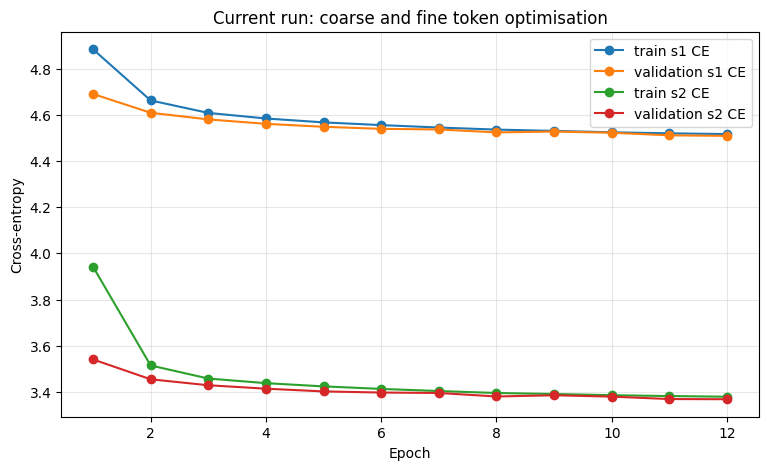

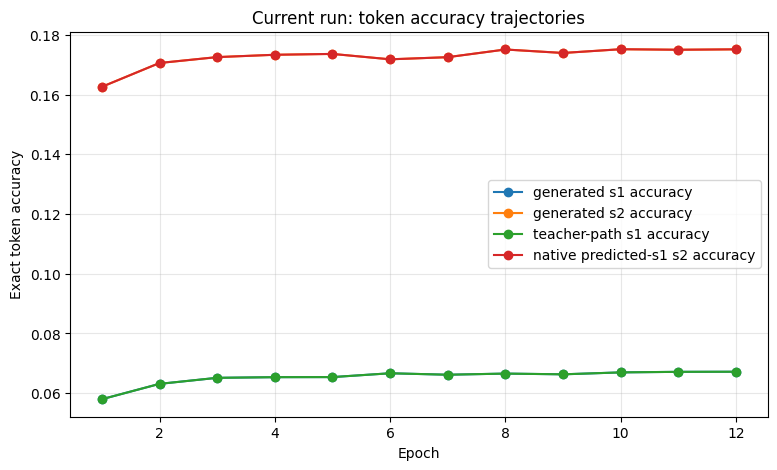

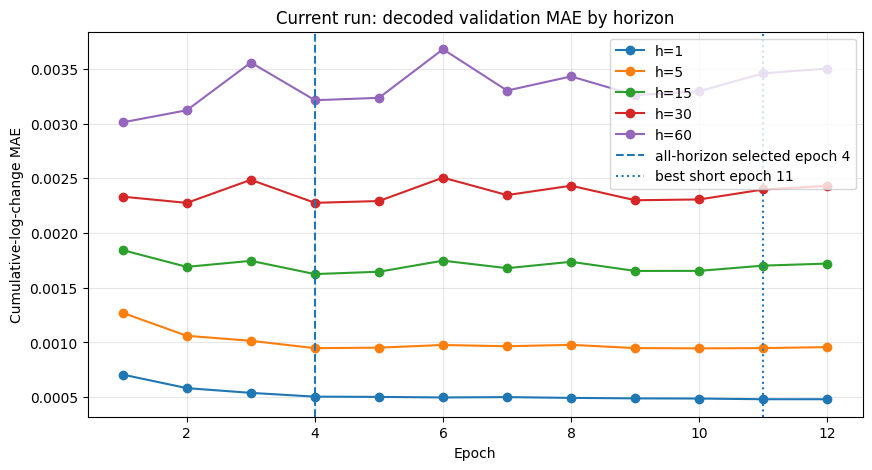

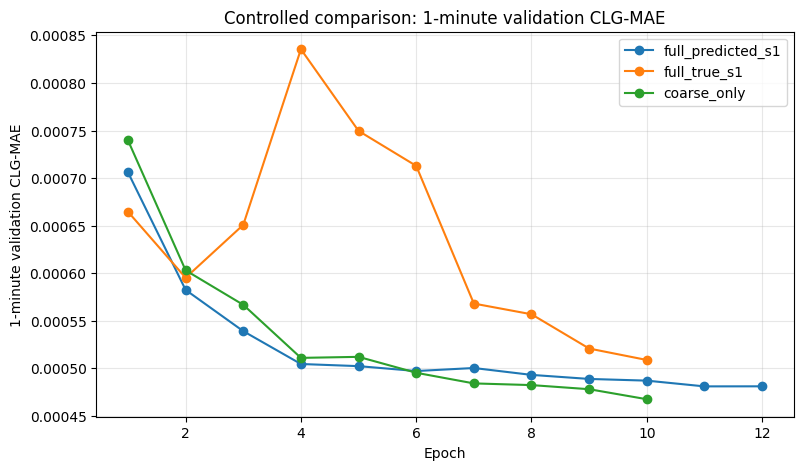

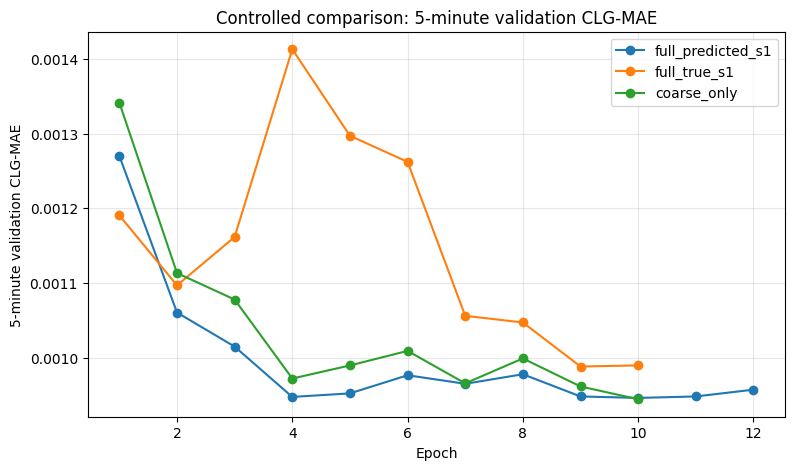

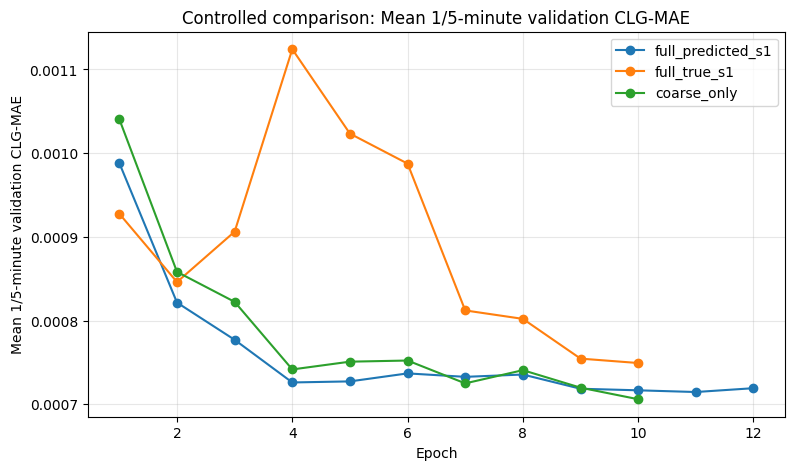

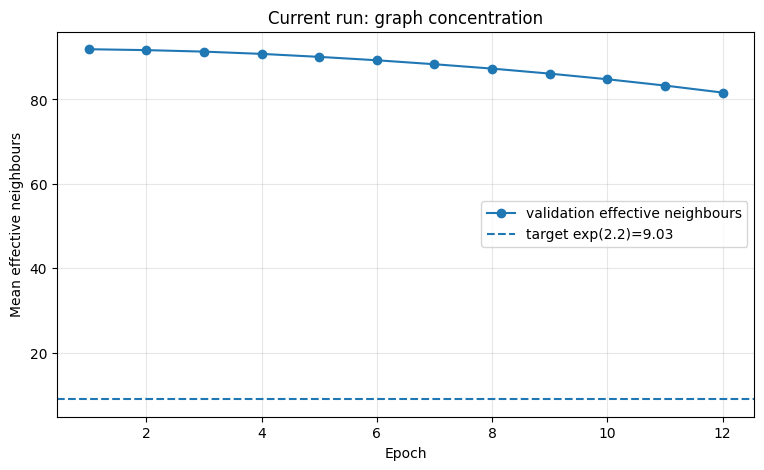

Saved all-horizon-best evaluation metrics


,metric,horizon,channel,value
0,cumulative_log_change_mae,1,close,0.000505
1,cumulative_log_change_mae,5,close,0.000947
2,cumulative_log_change_mae,15,close,0.001624
3,cumulative_log_change_mae,30,close,0.002275
4,cumulative_log_change_mae,60,close,0.003213
5,cumulative_log_change_pearson_correlation,1,close,0.012535
6,cumulative_log_change_pearson_correlation,5,close,0.045375
7,cumulative_log_change_pearson_correlation,15,close,0.040090
8,cumulative_log_change_pearson_correlation,30,close,0.022534
9,cumulative_log_change_pearson_correlation,60,close,0.026721


In [6]:
# Cell 6 — learning trajectories and compact controlled comparison.

histories = {
    "full_predicted_s1": history_with_selection_scores(history),
    "full_true_s1": history_with_selection_scores(
        reference_runs["full_true_s1"]["history"]
    ),
    "coarse_only": history_with_selection_scores(
        reference_runs["coarse_only"]["history"]
    ),
}

selection_rows: list[dict[str, Any]] = []
selection_criteria = {
    "best_short": "short_clg_mae",
    "best_all": "primary_score",
    "best_token_ce": "validation_token_loss",
    "best_s1_ce": "validation_s1_loss",
}

for run_name, run_history in histories.items():
    for selection_name, column in selection_criteria.items():
        row = best_history_row(run_history, column)
        selection_rows.append(
            {
                "run": run_name,
                "selection": selection_name,
                "epoch": int(row["epoch"]),
                "h1_clg_mae": float(row["val/cumulative_log_change_mae/h1"]),
                "h5_clg_mae": float(row["val/cumulative_log_change_mae/h5"]),
                "short_clg_mae": float(row["short_clg_mae"]),
                "h15_clg_mae": float(row["val/cumulative_log_change_mae/h15"]),
                "h30_clg_mae": float(row["val/cumulative_log_change_mae/h30"]),
                "h60_clg_mae": float(row["val/cumulative_log_change_mae/h60"]),
                "all_horizon_score": float(row["primary_score"]),
                "validation_token_ce": float(row["validation_token_loss"]),
                "validation_s1_ce": float(row["validation_s1_loss"]),
                "validation_s2_ce": float(row.get("validation_s2_loss", float("nan"))),
                "generated_s1_accuracy": float(row["generated_s1_accuracy"]),
                "generated_s2_accuracy": float(row.get("generated_s2_accuracy", float("nan"))),
                "invalid_dense_candle_rate_percent": float(
                    row.get("invalid_dense_candle_rate_percent", float("nan"))
                ),
                "graph_effective_neighbours": float(
                    row.get("validation_graph_mean_effective_neighbours", float("nan"))
                ),
            }
        )

    last_row = run_history.iloc[-1]
    selection_rows.append(
        {
            "run": run_name,
            "selection": "last",
            "epoch": int(last_row["epoch"]),
            "h1_clg_mae": float(last_row["val/cumulative_log_change_mae/h1"]),
            "h5_clg_mae": float(last_row["val/cumulative_log_change_mae/h5"]),
            "short_clg_mae": float(last_row["short_clg_mae"]),
            "h15_clg_mae": float(last_row["val/cumulative_log_change_mae/h15"]),
            "h30_clg_mae": float(last_row["val/cumulative_log_change_mae/h30"]),
            "h60_clg_mae": float(last_row["val/cumulative_log_change_mae/h60"]),
            "all_horizon_score": float(last_row["primary_score"]),
            "validation_token_ce": float(last_row["validation_token_loss"]),
            "validation_s1_ce": float(last_row["validation_s1_loss"]),
            "validation_s2_ce": float(last_row.get("validation_s2_loss", float("nan"))),
            "generated_s1_accuracy": float(last_row["generated_s1_accuracy"]),
            "generated_s2_accuracy": float(last_row.get("generated_s2_accuracy", float("nan"))),
            "invalid_dense_candle_rate_percent": float(
                last_row.get("invalid_dense_candle_rate_percent", float("nan"))
            ),
            "graph_effective_neighbours": float(
                last_row.get("validation_graph_mean_effective_neighbours", float("nan"))
            ),
        }
    )

selection_epoch_table = pd.DataFrame(selection_rows)
short_candidate_table = (
    selection_epoch_table.loc[
        selection_epoch_table["selection"] == "best_short"
    ]
    .sort_values("short_clg_mae")
    .reset_index(drop=True)
)

print("Best short-horizon epoch for each run")
display(short_candidate_table)
print("All selection views")
display(selection_epoch_table.sort_values(["selection", "short_clg_mae"]))

# All common evaluator metrics at each run's own short-horizon-selected epoch.
common_metric_names = (
    "cumulative_log_change_mae",
    "cumulative_log_change_pearson_correlation",
    "cumulative_log_change_movement_magnitude_ratio",
    "cumulative_log_change_temporal_absolute_correlation",
    "mase",
    "relative_mae_vs_persistence",
    "persistence_win_rate",
    "cumulative_log_change_cross_sectional_pearson_ic",
    "cumulative_log_change_cross_sectional_spearman_rank_ic",
)
short_metric_rows = []
for run_name, run_history in histories.items():
    selected_row = best_history_row(run_history, "short_clg_mae")
    for horizon in (1, 5, 15, 30, 60):
        for metric_name in common_metric_names:
            column = f"val/{metric_name}/h{horizon}"
            if column in selected_row.index:
                short_metric_rows.append(
                    {
                        "run": run_name,
                        "selected_epoch": int(selected_row["epoch"]),
                        "horizon": horizon,
                        "metric": metric_name,
                        "value": float(selected_row[column]),
                    }
                )
short_selected_metric_table = pd.DataFrame(short_metric_rows)
print("Common evaluator metrics at each run's own best-short epoch")
display(short_selected_metric_table)

plt.figure(figsize=(9, 5))
for column, label in (
    ("train_s1_loss", "train s1 CE"),
    ("validation_s1_loss", "validation s1 CE"),
    ("train_s2_loss", "train s2 CE"),
    ("validation_s2_loss", "validation s2 CE"),
):
    if column in history:
        plt.plot(history["epoch"], history[column], marker="o", label=label)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.title("Current run: coarse and fine token optimisation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
for column, label in (
    ("generated_s1_accuracy", "generated s1 accuracy"),
    ("generated_s2_accuracy", "generated s2 accuracy"),
    ("validation_s1_accuracy", "teacher-path s1 accuracy"),
    ("validation_s2_accuracy", "native predicted-s1 s2 accuracy"),
):
    if column in history:
        plt.plot(history["epoch"], history[column], marker="o", label=label)
plt.xlabel("Epoch")
plt.ylabel("Exact token accuracy")
plt.title("Current run: token accuracy trajectories")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for horizon in evaluation_horizons:
    column = f"val/cumulative_log_change_mae/h{horizon}"
    plt.plot(history["epoch"], history[column], marker="o", label=f"h={horizon}")
plt.axvline(
    int(best_checkpoint["epoch"]),
    linestyle="--",
    label=f"all-horizon selected epoch {best_checkpoint['epoch']}",
)
plt.axvline(
    int(best_short_epoch),
    linestyle=":",
    label=f"best short epoch {best_short_epoch}",
)
plt.xlabel("Epoch")
plt.ylabel("Cumulative-log-change MAE")
plt.title("Current run: decoded validation MAE by horizon")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for metric_column, metric_title in (
    ("val/cumulative_log_change_mae/h1", "1-minute validation CLG-MAE"),
    ("val/cumulative_log_change_mae/h5", "5-minute validation CLG-MAE"),
    ("short_clg_mae", "Mean 1/5-minute validation CLG-MAE"),
):
    plt.figure(figsize=(9, 5))
    for run_name, run_history in histories.items():
        plt.plot(
            run_history["epoch"],
            run_history[metric_column],
            marker="o",
            label=run_name,
        )
    plt.xlabel("Epoch")
    plt.ylabel(metric_title)
    plt.title(f"Controlled comparison: {metric_title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["validation_graph_mean_effective_neighbours"],
    marker="o",
    label="validation effective neighbours",
)
plt.axhline(
    math.exp(2.2),
    linestyle="--",
    label=f"target exp(2.2)={math.exp(2.2):.2f}",
)
plt.xlabel("Epoch")
plt.ylabel("Mean effective neighbours")
plt.title("Current run: graph concentration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Saved all-horizon-best evaluation metrics")
display(metric_table.reset_index(drop=True))

In [7]:
# Cell 7 — initial, best, and last graph states.

def extract_free_static_state(
    model: DynamicGraphTokenForecaster,
) -> tuple[Tensor, Tensor]:
    learner = model.graph_learners[0]

    if not hasattr(learner, "logits") or not hasattr(
        learner, "singleton_adjacency"
    ):
        raise TypeError("Model does not contain a free-static graph learner.")

    logits = learner.logits.detach().cpu().clone()
    adjacency = learner.singleton_adjacency()[0].detach().cpu().clone()
    return logits, adjacency


initial_logits, initial_graph = extract_free_static_state(initial_model_cpu)
best_logits, best_graph = extract_free_static_state(best_model_cpu)
last_logits, last_graph = extract_free_static_state(last_model_cpu)

graph_state_table = pd.DataFrame(
    [
        graph_statistics("initial", initial_graph),
        graph_statistics("best", best_graph),
        graph_statistics("last", last_graph),
    ]
)

graph_movement_table = pd.DataFrame(
    [
        graph_pair_statistics(
            "initial",
            initial_logits,
            initial_graph,
            "best",
            best_logits,
            best_graph,
        ),
        graph_pair_statistics(
            "initial",
            initial_logits,
            initial_graph,
            "last",
            last_logits,
            last_graph,
        ),
        graph_pair_statistics(
            "best",
            best_logits,
            best_graph,
            "last",
            last_logits,
            last_graph,
        ),
    ]
)

# Free-static train/eval graph construction should be exactly deterministic.
dummy_hidden = torch.zeros(
    2,
    int(model_config["context_length"]),
    int(model_config["num_nodes"]),
    int(model_config["d_model"]),
)

best_learner = best_model_cpu.graph_learners[0]
best_learner.train()
train_graph_1 = best_learner(dummy_hidden).selected.detach().cpu()
train_graph_2 = best_learner(dummy_hidden).selected.detach().cpu()
best_learner.eval()
evaluation_graph = best_learner(dummy_hidden).selected.detach().cpu()

if not torch.equal(train_graph_1, train_graph_2):
    raise AssertionError("Free-static training graph is stochastic.")

if not torch.equal(train_graph_1, evaluation_graph):
    raise AssertionError("Free-static train and evaluation graphs differ.")

print("Repeated train/eval graph equality: True")
display(graph_state_table)
display(graph_movement_table)

# Compare parameter movement across the complete model. This contextualises
# the free-static graph movement against the temporal, spatial and future
# predictor modules.
def model_parameter_movement(
    first_model: DynamicGraphTokenForecaster,
    second_model: DynamicGraphTokenForecaster,
    *,
    comparison: str,
) -> pd.DataFrame:
    first_parameters = dict(first_model.named_parameters())
    second_parameters = dict(second_model.named_parameters())
    accumulator: dict[str, dict[str, float]] = defaultdict(
        lambda: {
            "difference_squared": 0.0,
            "first_squared": 0.0,
            "num_parameters": 0.0,
            "maximum_absolute_change": 0.0,
        }
    )

    for parameter_name, second_parameter in second_parameters.items():
        first_parameter = first_parameters[parameter_name]
        difference = (
            second_parameter.detach().to(torch.float64)
            - first_parameter.detach().to(torch.float64)
        )
        group = module_group(parameter_name)
        accumulator[group]["difference_squared"] += float(
            difference.square().sum()
        )
        accumulator[group]["first_squared"] += float(
            first_parameter.detach().to(torch.float64).square().sum()
        )
        accumulator[group]["num_parameters"] += int(second_parameter.numel())
        accumulator[group]["maximum_absolute_change"] = max(
            accumulator[group]["maximum_absolute_change"],
            float(difference.abs().max()),
        )

    rows = []
    for group, values in sorted(accumulator.items()):
        difference_norm = math.sqrt(values["difference_squared"])
        first_norm = math.sqrt(values["first_squared"])
        num_parameters = max(int(values["num_parameters"]), 1)
        rows.append(
            {
                "comparison": comparison,
                "module": group,
                "parameters": num_parameters,
                "absolute_l2_change": difference_norm,
                "relative_l2_change": difference_norm / max(first_norm, 1.0e-12),
                "rms_parameter_change": difference_norm / math.sqrt(num_parameters),
                "maximum_absolute_change": values["maximum_absolute_change"],
            }
        )

    return pd.DataFrame(rows)


parameter_movement_table = pd.concat(
    [
        model_parameter_movement(
            initial_model_cpu,
            best_model_cpu,
            comparison="initial -> best",
        ),
        model_parameter_movement(
            initial_model_cpu,
            last_model_cpu,
            comparison="initial -> last",
        ),
    ],
    ignore_index=True,
)

# Read Adam moments from the best checkpoint. Parameter ordering in an
# optimiser state dict follows model.named_parameters() for this runner.
optimizer_state = best_checkpoint["optimizer_state_dict"]
saved_parameter_ids = [
    parameter_id
    for group in optimizer_state["param_groups"]
    for parameter_id in group["params"]
]
named_parameter_list = list(best_model_cpu.named_parameters())

if len(saved_parameter_ids) != len(named_parameter_list):
    raise AssertionError(
        "Optimizer parameter IDs do not align with model parameters."
    )

optimizer_accumulator: dict[str, dict[str, float]] = defaultdict(
    lambda: {
        "first_moment_squared": 0.0,
        "second_moment_sum": 0.0,
        "num_values": 0.0,
    }
)

for parameter_id, (parameter_name, parameter) in zip(
    saved_parameter_ids,
    named_parameter_list,
    strict=True,
):
    state = optimizer_state["state"].get(parameter_id, {})
    first_moment = state.get("exp_avg")
    second_moment = state.get("exp_avg_sq")

    if first_moment is None:
        continue

    group = module_group(parameter_name)
    optimizer_accumulator[group]["first_moment_squared"] += float(
        first_moment.detach().to(torch.float64).square().sum()
    )
    if second_moment is not None:
        optimizer_accumulator[group]["second_moment_sum"] += float(
            second_moment.detach().to(torch.float64).sum()
        )
    optimizer_accumulator[group]["num_values"] += int(parameter.numel())

optimizer_rows = []
for group, values in sorted(optimizer_accumulator.items()):
    num_values = max(int(values["num_values"]), 1)
    optimizer_rows.append(
        {
            "module": group,
            "adam_first_moment_rms": math.sqrt(
                values["first_moment_squared"] / num_values
            ),
            "adam_second_moment_mean": values["second_moment_sum"] / num_values,
        }
    )

optimizer_moment_table = pd.DataFrame(optimizer_rows)

display(
    parameter_movement_table.sort_values(
        ["comparison", "relative_l2_change"],
        ascending=[True, False],
    )
)
display(
    optimizer_moment_table.sort_values(
        "adam_first_moment_rms",
        ascending=False,
    )
)


Repeated train/eval graph equality: True


,state,mean_row_entropy,mean_effective_neighbours,mean_nonzero_sources,off_diagonal_weight_mean,off_diagonal_weight_std,minimum_off_diagonal_weight,maximum_edge_weight,mean_top_1_row_mass,mean_top_5_row_mass,mean_top_10_row_mass,mean_top_20_row_mass,source_mass_std,maximum_source_mass,head_off_diagonal_correlation
0,initial,4.521586,91.981347,92.0,0.01087,0.000219,0.010030,0.011740,0.011425,0.056568,0.112456,0.223309,0.002067,1.005018,0.005482
1,best,4.508374,90.774238,92.0,0.01087,0.001794,0.006735,0.017672,0.015646,0.073926,0.142031,0.269484,0.024196,1.057910,0.045232
2,last,4.401694,81.610877,92.0,0.01087,0.005599,0.002917,0.040464,0.029323,0.126786,0.227423,0.391581,0.078436,1.205949,0.052323


,comparison,off_diagonal_logit_l2_change,off_diagonal_logit_rms_change,off_diagonal_logit_relative_l2_change,maximum_absolute_logit_change,adjacency_l2_change,adjacency_rms_change,maximum_absolute_edge_change,adjacency_correlation
0,initial -> best,18.911261,0.144567,7.131600,0.417994,0.207858,0.001589,0.005950,0.942345
1,initial -> last,62.200857,0.475495,23.456479,1.263236,0.707336,0.005407,0.028855,0.881031
2,best -> last,43.872129,0.335381,2.051461,0.848887,0.508090,0.003884,0.022984,0.969923


,comparison,module,parameters,absolute_l2_change,relative_l2_change,rms_parameter_change,maximum_absolute_change
1,initial -> best,graph_learner,17298,18.911261,7.095588,0.143788,0.417994
3,initial -> best,s2_head,74944,22.416277,1.080055,0.081883,0.290980
2,initial -> best,s1_classifier,66560,10.517017,0.564402,0.040765,0.278487
0,initial -> best,future_predictor_shared,54208,10.178306,0.431297,0.043716,0.515031
6,initial -> best,token_embedding,140992,4.568314,0.416376,0.012166,0.107218
5,initial -> best,temporal_encoder,33472,3.466673,0.197016,0.018948,0.123384
4,initial -> best,spatial_module,25152,2.167243,0.141019,0.013665,0.066642
8,initial -> last,graph_learner,17298,62.200857,23.338033,0.472932,1.263236
10,initial -> last,s2_head,74944,39.928741,1.923836,0.145854,0.611226
9,initial -> last,s1_classifier,66560,20.538408,1.102207,0.079609,0.504325


,module,adam_first_moment_rms,adam_second_moment_mean
0,future_predictor_shared,0.000312,3.412575e-06
6,token_embedding,0.000296,2.625532e-06
4,spatial_module,0.000278,3.282059e-06
3,s2_head,0.000210,3.605033e-06
2,s1_classifier,0.000160,7.533785e-07
5,temporal_encoder,0.000157,1.201543e-06
1,graph_learner,0.000001,6.664371e-12


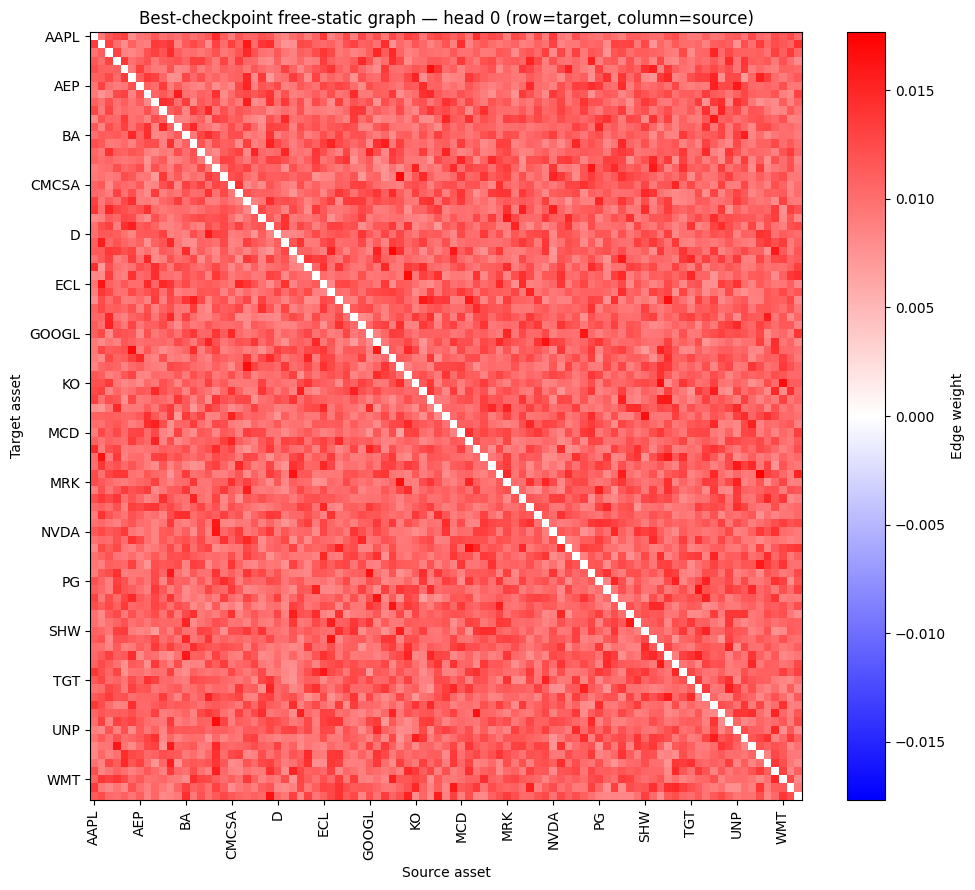

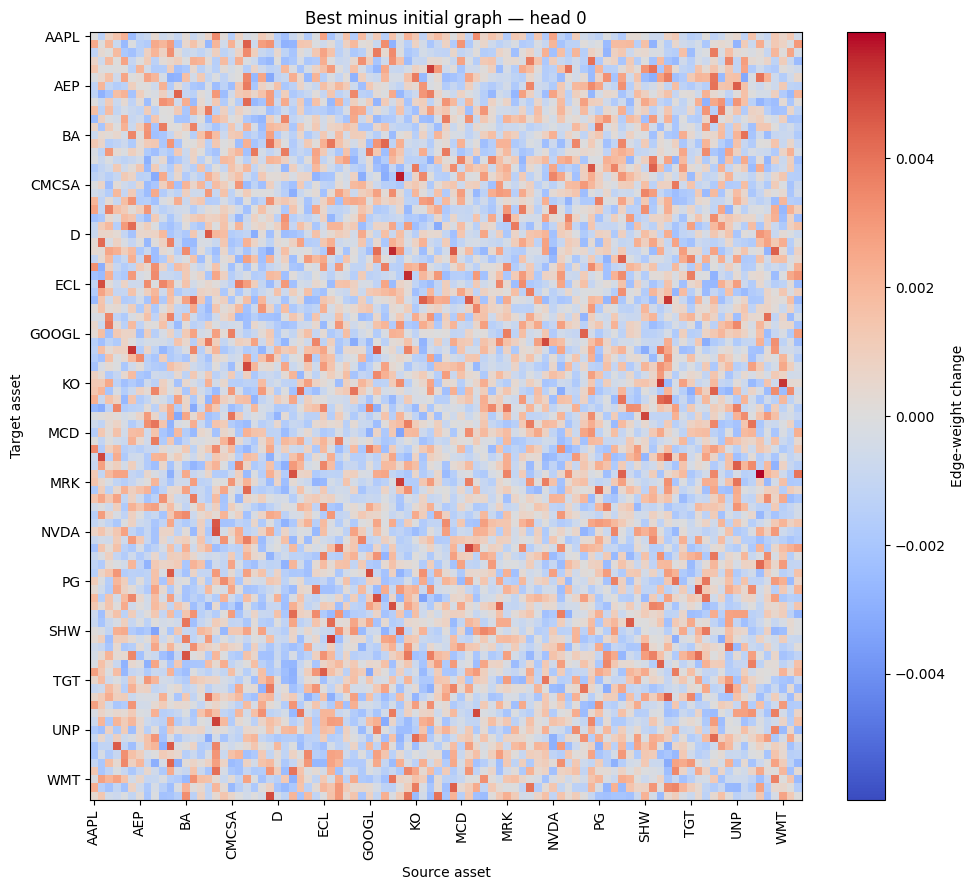

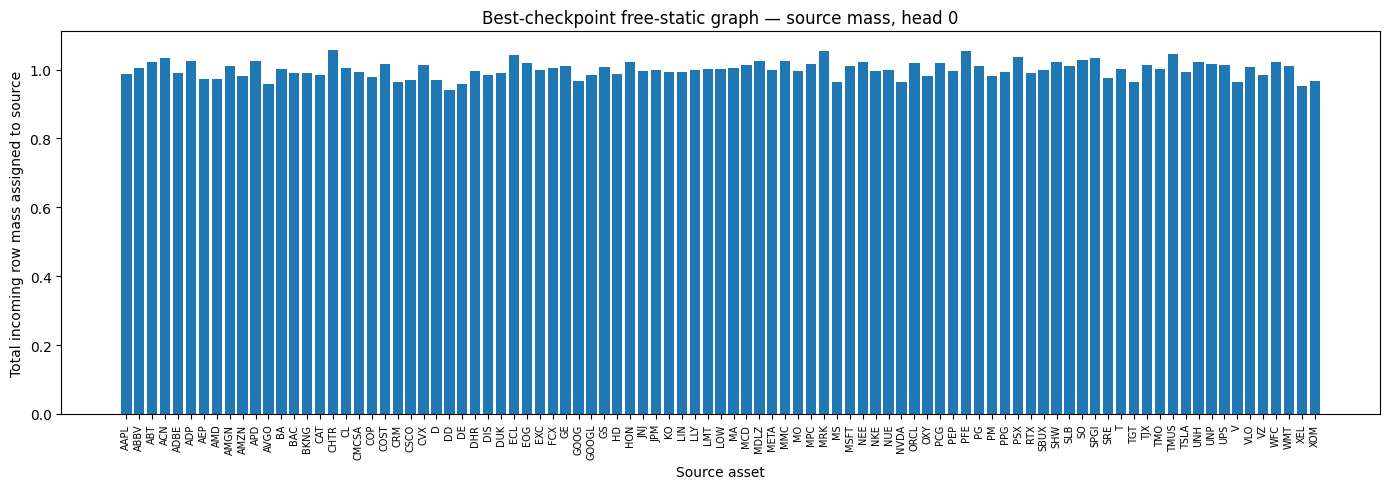

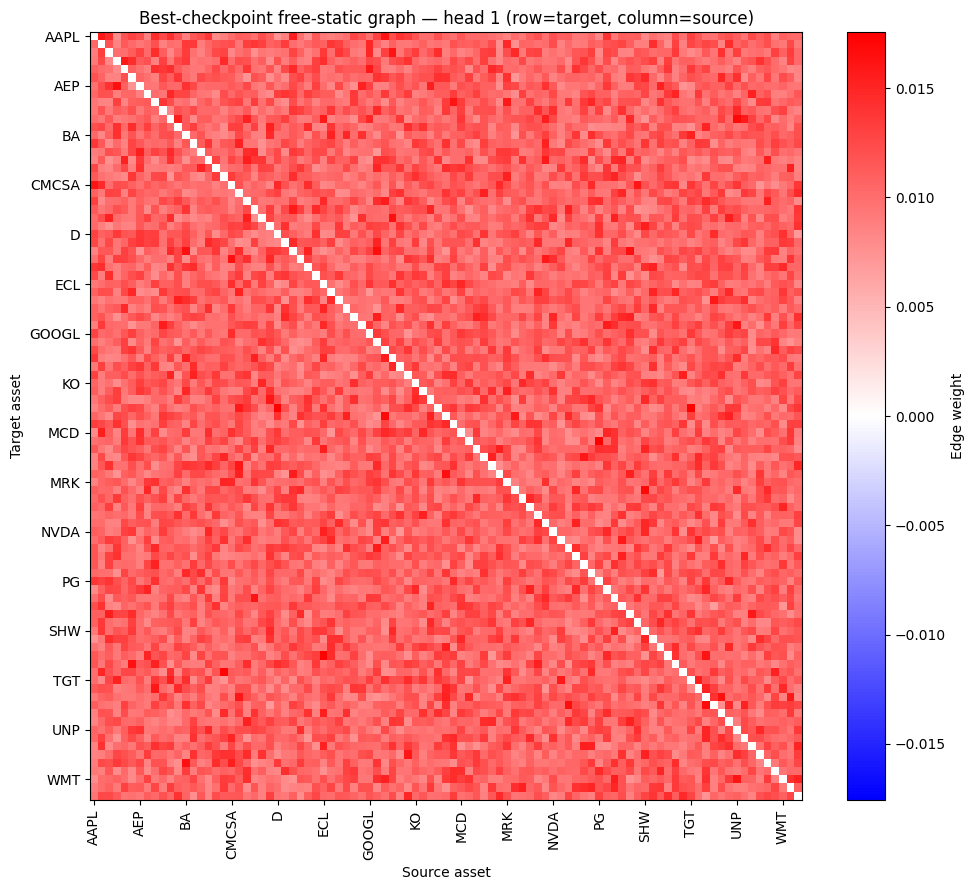

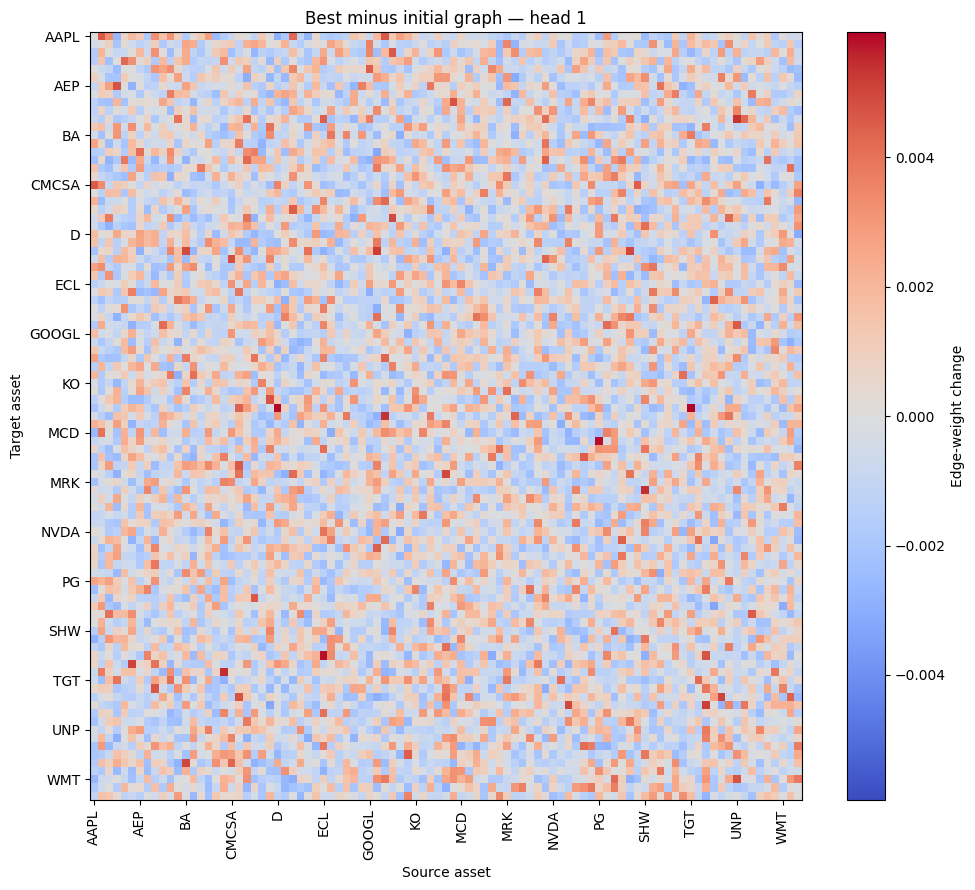

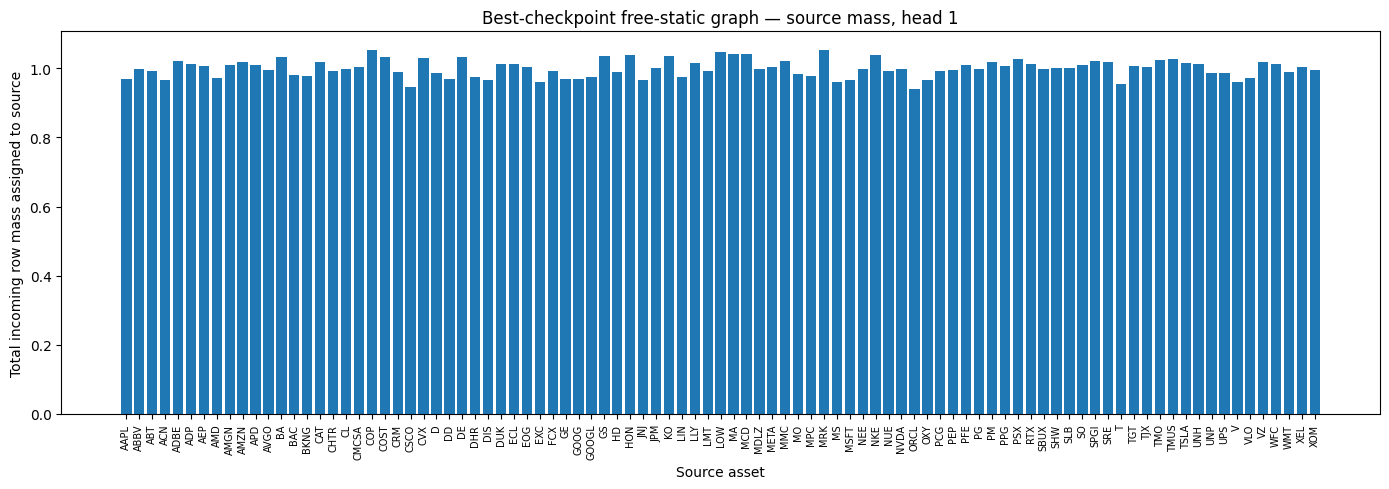

Largest directed edges at the best checkpoint


,head,rank,target,source,weight
0,0,1,MPC,VLO,0.017672
1,0,2,CL,JNJ,0.017238
2,0,3,DE,HON,0.017002
3,0,4,HD,ADP,0.016942
4,0,5,DUK,JPM,0.016880
5,0,6,KO,WMT,0.016798
6,0,7,ADBE,LLY,0.016780
7,0,8,UNH,CHTR,0.016779
8,0,9,EXC,SPGI,0.016775
9,0,10,KO,SO,0.016709


In [8]:
# Cell 8 — graph heat maps, differences, source mass, and top edges.

def plot_graph_heatmap(
    adjacency: Tensor,
    *,
    title: str,
    head: int,
    label_stride: int = 6,
) -> None:
    matrix = adjacency[head].detach().cpu().numpy()
    plt.figure(figsize=(10, 9))
    image = plt.imshow(matrix, aspect="auto", interpolation="nearest",cmap="bwr",norm=mcolors.CenteredNorm())
    plt.colorbar(image, label="Edge weight")
    tick_positions = list(range(0, len(asset_cols), label_stride))
    tick_labels = [asset_cols[position] for position in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.yticks(tick_positions, tick_labels)
    plt.xlabel("Source asset")
    plt.ylabel("Target asset")
    plt.title(f"{title} — head {head} (row=target, column=source)")
    plt.tight_layout()
    plt.show()


def plot_graph_difference(
    first: Tensor,
    second: Tensor,
    *,
    title: str,
    head: int,
    label_stride: int = 6,
) -> None:
    matrix = (second[head] - first[head]).detach().cpu().numpy()
    limit = float(np.max(np.abs(matrix)))
    plt.figure(figsize=(10, 9))
    image = plt.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        vmin=-limit,
        vmax=limit,
        cmap="coolwarm",
    )
    plt.colorbar(image, label="Edge-weight change")
    tick_positions = list(range(0, len(asset_cols), label_stride))
    tick_labels = [asset_cols[position] for position in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.yticks(tick_positions, tick_labels)
    plt.xlabel("Source asset")
    plt.ylabel("Target asset")
    plt.title(f"{title} — head {head}")
    plt.tight_layout()
    plt.show()


def plot_source_mass(adjacency: Tensor, *, title: str, head: int) -> None:
    source_mass = adjacency[head].sum(dim=0).detach().cpu().numpy()
    plt.figure(figsize=(14, 5))
    plt.bar(np.arange(len(asset_cols)), source_mass)
    plt.xticks(
        np.arange(len(asset_cols)),
        asset_cols,
        rotation=90,
        fontsize=7,
    )
    plt.xlabel("Source asset")
    plt.ylabel("Total incoming row mass assigned to source")
    plt.title(f"{title} — source mass, head {head}")
    plt.tight_layout()
    plt.show()


for graph_head in range(int(best_graph.shape[0])):
    plot_graph_heatmap(
        best_graph,
        title="Best-checkpoint free-static graph",
        head=graph_head,
    )
    plot_graph_difference(
        initial_graph,
        best_graph,
        title="Best minus initial graph",
        head=graph_head,
    )
    plot_source_mass(
        best_graph,
        title="Best-checkpoint free-static graph",
        head=graph_head,
    )

print("Largest directed edges at the best checkpoint")
display(top_edges_table(best_graph, edges_per_head=25))


In [9]:
# Cell 9 — native predicted-s1 s1/s2 gradients and graph influence on one real batch.

gradient_batch = collate_cache_items(
    train_dataset,
    list(range(GRADIENT_BATCH_SIZE)),
)

context_tokens = gradient_batch["context_tokens"].long()
target_s1 = gradient_batch["target_s1"].long()
target_s2 = gradient_batch["target_s2"].long()

print(f'Detailed gradient checkpoint: {diagnostic_checkpoint_label}, epoch {diagnostic_epoch}')

gradient_model = copy.deepcopy(diagnostic_model_cpu)
gradient_model.train()

gradient_output = gradient_model(
    context_tokens,
    target_s1=target_s1,
    target_s2=target_s2,
)

s1_loss = F.cross_entropy(
    gradient_output.s1_logits.reshape(-1, gradient_output.s1_logits.shape[-1]),
    target_s1.reshape(-1),
)

if gradient_output.s2_logits is None:
    raise RuntimeError("The full-token run did not return s2 logits.")

s2_loss = F.cross_entropy(
    gradient_output.s2_logits.reshape(-1, gradient_output.s2_logits.shape[-1]),
    target_s2.reshape(-1),
)

named_parameters = [
    (name, parameter)
    for name, parameter in gradient_model.named_parameters()
    if parameter.requires_grad
]
parameters = [parameter for _, parameter in named_parameters]

s1_gradients = torch.autograd.grad(
    s1_loss,
    parameters,
    retain_graph=True,
    allow_unused=True,
)
s2_gradients = torch.autograd.grad(
    s2_loss,
    parameters,
    retain_graph=False,
    allow_unused=True,
)

gradient_accumulator: dict[str, dict[str, float]] = defaultdict(
    lambda: {
        "s1_squared": 0.0,
        "s2_squared": 0.0,
        "dot": 0.0,
        "num_values": 0.0,
    }
)

graph_parameter_diagnostics: dict[str, float] = {}

for (
    (parameter_name, parameter),
    s1_gradient,
    s2_gradient,
) in zip(
    named_parameters,
    s1_gradients,
    s2_gradients,
    strict=True,
):
    group = module_group(parameter_name)
    gradient_accumulator[group]["num_values"] += int(parameter.numel())

    if s1_gradient is not None:
        s1_gradient_64 = s1_gradient.detach().to(torch.float64)
        gradient_accumulator[group]["s1_squared"] += float(
            s1_gradient_64.square().sum()
        )
    else:
        s1_gradient_64 = None

    if s2_gradient is not None:
        s2_gradient_64 = s2_gradient.detach().to(torch.float64)
        gradient_accumulator[group]["s2_squared"] += float(
            s2_gradient_64.square().sum()
        )
    else:
        s2_gradient_64 = None

    if s1_gradient_64 is not None and s2_gradient_64 is not None:
        gradient_accumulator[group]["dot"] += float(
            (s1_gradient_64 * s2_gradient_64).sum()
        )

    if parameter_name == "graph_learners.0.logits":
        mask = (
            off_diagonal_mask(int(parameter.shape[-1]))
            .unsqueeze(0)
            .expand_as(s1_gradient_64)
        )
        if s1_gradient_64 is None or s2_gradient_64 is None:
            raise RuntimeError("Free-static graph logits did not receive gradients.")

        graph_parameter_diagnostics = {
            "s1_off_diagonal_gradient_norm": float(s1_gradient_64[mask].norm()),
            "s1_off_diagonal_gradient_rms": float(
                s1_gradient_64[mask].norm()
                / math.sqrt(s1_gradient_64[mask].numel())
            ),
            "s2_off_diagonal_gradient_norm": float(s2_gradient_64[mask].norm()),
            "s2_off_diagonal_gradient_rms": float(
                s2_gradient_64[mask].norm()
                / math.sqrt(s2_gradient_64[mask].numel())
            ),
            "maximum_absolute_s1_diagonal_gradient": float(
                torch.diagonal(s1_gradient_64, dim1=-2, dim2=-1).abs().max()
            ),
            "maximum_absolute_s2_diagonal_gradient": float(
                torch.diagonal(s2_gradient_64, dim1=-2, dim2=-1).abs().max()
            ),
        }

gradient_rows = []

for group, values in sorted(gradient_accumulator.items()):
    s1_norm = math.sqrt(values["s1_squared"])
    s2_norm = math.sqrt(values["s2_squared"])
    denominator = s1_norm * s2_norm
    num_values = max(int(values["num_values"]), 1)

    gradient_rows.append(
        {
            "module": group,
            "s1_gradient_norm": s1_norm,
            "s2_gradient_norm": s2_norm,
            "s1_gradient_rms": s1_norm / math.sqrt(num_values),
            "s2_gradient_rms": s2_norm / math.sqrt(num_values),
            "s2_to_s1_norm_ratio": s2_norm / max(s1_norm, 1.0e-20),
            "s1_s2_gradient_cosine": (
                values["dot"] / denominator
                if denominator > 0
                else float("nan")
            ),
        }
    )

gradient_table = pd.DataFrame(gradient_rows)
graph_gradient_table = pd.DataFrame([graph_parameter_diagnostics])

# Measure how much the spatial module changes the temporal representation.
spatial_model = copy.deepcopy(diagnostic_model_cpu).eval()

with torch.inference_mode():
    embedded = spatial_model.token_embedding(context_tokens)
    pre_spatial = spatial_model.temporal_blocks[0](embedded)
    graph_output = spatial_model.graph_learners[0](pre_spatial)
    adjacency = graph_output.selected

    spatial_layer = spatial_model.spatial_blocks[0].layers[0]
    batch_size, num_steps, num_nodes, hidden_dim = pre_spatial.shape

    values = (
        spatial_layer.value_projection(pre_spatial)
        .view(
            batch_size,
            num_steps,
            num_nodes,
            spatial_layer.num_heads,
            spatial_layer.head_dim,
        )
        .permute(0, 1, 3, 2, 4)
    )

    messages = aggregate_graph_values(adjacency, values)
    messages = (
        messages.permute(0, 1, 3, 2, 4)
        .reshape(batch_size, num_steps, num_nodes, hidden_dim)
    )
    messages = spatial_layer.output_projection(messages)
    post_spatial = spatial_model.spatial_blocks[0](pre_spatial, adjacency)

    # Isolate the effect of learned graph movement by substituting the
    # reconstructed initial graph logits into an otherwise trained model.
    initial_graph_substitution = copy.deepcopy(diagnostic_model_cpu).eval()
    initial_graph_substitution.graph_learners[0].logits.copy_(initial_logits)

    best_output = diagnostic_model_cpu(
        context_tokens,
        target_s1=target_s1,
        target_s2=target_s2,
    )
    initial_graph_output = initial_graph_substitution(
        context_tokens,
        target_s1=target_s1,
        target_s2=target_s2,
    )

spatial_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "s1 scalar loss",
            "value": float(s1_loss),
        },
        {
            "diagnostic": "s2 scalar loss",
            "value": float(s2_loss),
        },
        {
            "diagnostic": "s2 share of s1+s2 scalar loss",
            "value": float(s2_loss / (s1_loss + s2_loss)),
        },
        {
            "diagnostic": "graph-message norm / pre-spatial norm",
            "value": float(
                messages.norm() / pre_spatial.norm().clamp_min(1.0e-12)
            ),
        },
        {
            "diagnostic": "post-spatial change / pre-spatial norm",
            "value": float(
                (post_spatial - pre_spatial).norm()
                / pre_spatial.norm().clamp_min(1.0e-12)
            ),
        },
        {
            "diagnostic": "pre/post-spatial cosine",
            "value": float(
                F.cosine_similarity(
                    pre_spatial.reshape(-1),
                    post_spatial.reshape(-1),
                    dim=0,
                )
            ),
        },
        {
            "diagnostic": "mean |s1 logits(diagnostic graph)-s1 logits(initial graph)|",
            "value": float(
                (
                    best_output.s1_logits
                    - initial_graph_output.s1_logits
                ).abs().mean()
            ),
        },
        {
            "diagnostic": "s1 argmax change rate from initial->diagnostic graph",
            "value": float(
                (
                    best_output.s1_logits.argmax(dim=-1)
                    != initial_graph_output.s1_logits.argmax(dim=-1)
                ).to(torch.float64).mean()
            ),
        },
    ]
)

display(gradient_table)
display(graph_gradient_table)
display(spatial_diagnostics)

# Retain these for the final summary cell.
free_static_graph_gradient_rms = graph_parameter_diagnostics[
    "s1_off_diagonal_gradient_rms"
]


Detailed gradient checkpoint: last_fallback, epoch 12


/var/folders/kg/dmc2syn91z73sggtrcv8x2480000gn/T/ipykernel_85200/2837159384.py:208: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  "value": float(s1_loss),


,module,s1_gradient_norm,s2_gradient_norm,s1_gradient_rms,s2_gradient_rms,s2_to_s1_norm_ratio,s1_s2_gradient_cosine
0,future_predictor_shared,0.527931,0.615505,0.002267,0.002644,1.165880e+00,0.842287
1,graph_learner,0.001535,0.001340,0.000012,0.000010,8.730063e-01,0.919231
2,s1_classifier,0.453065,0.000000,0.001756,0.000000,0.000000e+00,NaN
3,s2_head,0.000000,1.262967,0.000000,0.004613,1.262967e+20,NaN
4,spatial_module,0.385503,0.441094,0.002431,0.002781,1.144201e+00,0.922853
5,temporal_encoder,0.347920,0.384176,0.001902,0.002100,1.104207e+00,0.955503
6,token_embedding,0.944184,1.022950,0.002515,0.002724,1.083423e+00,0.946076


,s1_off_diagonal_gradient_norm,s1_off_diagonal_gradient_rms,s2_off_diagonal_gradient_norm,s2_off_diagonal_gradient_rms,maximum_absolute_s1_diagonal_gradient,maximum_absolute_s2_diagonal_gradient
0,0.001535,0.000012,0.00134,0.00001,0.0,0.0


,diagnostic,value
0,s1 scalar loss,4.079095
1,s2 scalar loss,2.973283
2,s2 share of s1+s2 scalar loss,0.421600
3,graph-message norm / pre-spatial norm,0.270471
4,post-spatial change / pre-spatial norm,0.480953
5,pre/post-spatial cosine,0.884026
6,mean |s1 logits(diagnostic graph)-s1 logits(in...,0.027338
7,s1 argmax change rate from initial->diagnostic...,0.015323


,future_step,is_evaluation_horizon,s1_ce,s1_top1,s1_top5,s1_top10,s1_bit_accuracy,s1_predictive_entropy,s2_ce_native_predicted_s1,s2_ce_counterfactual_true_s1,...,mean_true_token_probability,mean_selected_token_probability,mean_probability_gap,mean_true_to_selected_ratio,mean_top1_top2_margin,mean_top5_probability_mass,mean_top10_probability_mass,mean_true_token_rank,training_marginal_s1_mode_accuracy,training_marginal_s2_mode_accuracy
0,1,True,3.977560,0.109677,0.333928,0.484154,0.703147,4.103967,2.763561,2.762467,...,0.034209,0.089739,0.055531,0.385226,0.024833,0.289482,0.435139,24.116723,0.047736,0.145897
1,5,True,4.281158,0.078268,0.262564,0.396774,0.655286,4.318039,3.044814,3.043444,...,0.025853,0.076709,0.050856,0.340779,0.021412,0.250992,0.383353,31.174759,0.043237,0.140153
2,15,True,4.597429,0.059564,0.205801,0.320515,0.611938,4.550474,3.378801,3.377885,...,0.019238,0.063536,0.044298,0.308377,0.017416,0.212099,0.329453,41.620317,0.034748,0.125184
3,30,True,4.694523,0.056989,0.195727,0.304160,0.603319,4.657840,3.521653,3.519874,...,0.017434,0.059008,0.041574,0.302034,0.014753,0.199841,0.310428,45.364346,0.031296,0.115025
4,60,True,4.764647,0.058347,0.196350,0.302547,0.607032,4.735913,3.716970,3.713882,...,0.017044,0.060142,0.043098,0.289247,0.014587,0.201842,0.308051,49.344199,0.034126,0.093322


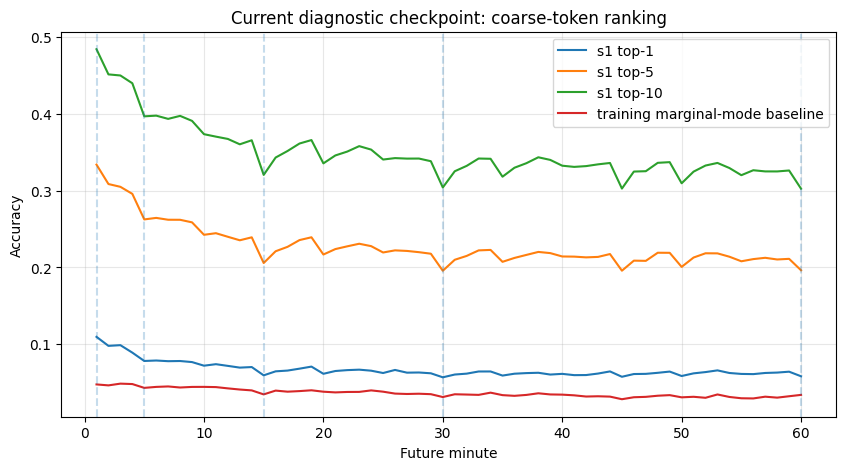

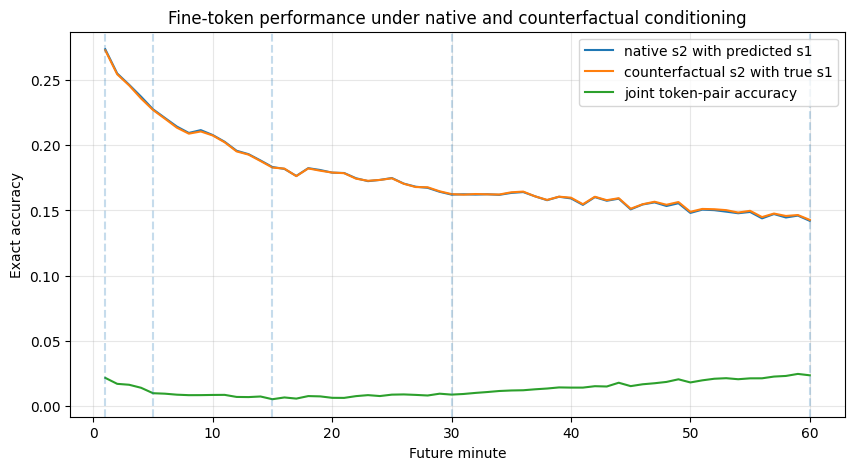

,stream,codes_used,effective_vocabulary,largest_code_share,top_10_share
0,true s1,726,134.328407,0.036066,0.235622
1,generated s1,65,8.887951,0.235818,0.956030
2,true s2,513,41.629726,0.119247,0.564841
3,generated native s2,16,4.271839,0.443274,0.999476
4,counterfactual true-s1-conditioned s2,17,4.298773,0.440680,0.999530


,condition,positions,native_generated_s2_accuracy
0,all,2120400,0.175133
1,s1_correct,142482,0.193042
2,s1_wrong,1977918,0.173842


,positions,mean_true_token_probability,mean_selected_token_probability,mean_probability_gap,mean_true_to_selected_ratio,mean_top1_top2_margin,mean_top5_probability_mass,mean_top10_probability_mass,mean_true_token_rank
0,2120400,0.021141,0.067929,0.046788,0.31365,0.017522,0.226697,0.346796,38.607234


Maximum saved-versus-recomputed s1 accuracy difference: 0.013978494623655913
Maximum saved-versus-recomputed s2 accuracy difference: 0.005291454442558019
Small differences are expected when the saved CUDA/AMP path is regenerated on another device or precision path.


In [10]:
# Cell 10 — full-validation token, exposure-gap, probability, and code-use diagnostics.

token_diagnostic_indices = select_stratified_windows(
    validation_cache["sample_idx"],
    max_windows=TOKEN_DIAGNOSTIC_WINDOWS,
    seed=DIAGNOSTIC_SEED,
)

if len(token_diagnostic_indices) != len(validation_dataset):
    print(
        "WARNING: token diagnostics use only",
        len(token_diagnostic_indices),
        "of",
        len(validation_dataset),
        "validation windows.",
    )

diagnostic_model = copy.deepcopy(diagnostic_model_cpu).to(MODEL_DEVICE).eval()
num_future_steps = int(model_config["heads"]["prediction_length"])

metric_names = (
    "count",
    "s1_ce",
    "s1_top1",
    "s1_top5",
    "s1_top10",
    "s1_bit_accuracy",
    "s1_predictive_entropy",
    "s2_native_ce",
    "s2_true_s1_counterfactual_ce",
    "s2_native_top1",
    "s2_true_s1_counterfactual_top1",
    "joint_pair_top1",
    "s2_bit_accuracy",
    "s2_native_predictive_entropy",
    "true_token_probability",
    "selected_token_probability",
    "probability_gap",
    "true_to_selected_ratio",
    "top1_top2_margin",
    "top5_probability_mass",
    "top10_probability_mass",
    "true_token_rank",
)
metric_sums = {
    name: torch.zeros(num_future_steps, dtype=torch.float64)
    for name in metric_names
}

stored_context_tokens = []
stored_true_s1 = []
stored_true_s2 = []
stored_generated_s1 = []
stored_generated_s2 = []
stored_true_s1_counterfactual_s2 = []

conditional_counts = {
    "all": 0,
    "s1_correct": 0,
    "s1_wrong": 0,
}
conditional_s2_correct = {
    "all": 0,
    "s1_correct": 0,
    "s1_wrong": 0,
}

with torch.inference_mode():
    for start in range(0, len(token_diagnostic_indices), TOKEN_DIAGNOSTIC_BATCH_SIZE):
        stop = min(
            start + TOKEN_DIAGNOSTIC_BATCH_SIZE,
            len(token_diagnostic_indices),
        )
        batch_indices = token_diagnostic_indices[start:stop]
        batch = collate_cache_items(validation_dataset, batch_indices)

        context = batch["context_tokens"].to(MODEL_DEVICE)
        true_s1 = batch["target_s1"].to(MODEL_DEVICE)
        true_s2 = batch["target_s2"].to(MODEL_DEVICE)

        generated = diagnostic_model.generate(context)

        if generated.forecast.s2_logits is None:
            raise RuntimeError("Full-token diagnostics require s2 logits.")

        # Verify the supervised path once. Under predicted-s1 conditioning,
        # target_s1 must not alter the structured-parallel s1 or s2 logits.
        if start == 0:
            native_output = diagnostic_model(
                context,
                target_s1=true_s1,
                target_s2=true_s2,
            )
            if native_output.s2_logits is None:
                raise RuntimeError("The supervised full-token path returned no s2 logits.")
            if not torch.equal(
                native_output.s1_logits.argmax(dim=-1),
                generated.token_ids[..., 0],
            ):
                raise AssertionError(
                    "Structured-parallel supervised and generated s1 paths differ."
                )
            if not torch.allclose(
                native_output.s2_logits,
                generated.forecast.s2_logits,
                atol=1.0e-7,
                rtol=1.0e-6,
            ):
                raise AssertionError(
                    "Predicted-s1 supervised and generated s2 logits differ."
                )

        s1_logits = generated.forecast.s1_logits
        native_s2_logits = generated.forecast.s2_logits
        generated_s1 = generated.token_ids[..., 0]
        generated_s2 = generated.token_ids[..., 1]

        # Counterfactual only: feed the true s1 into the same trained fine
        # head while preserving the current model's future hidden states.
        true_s1_counterfactual_s2_logits = (
            diagnostic_model.future_predictor.token_heads.s2_logits(
                generated.forecast.future_hidden,
                true_s1,
                s1_embedding=diagnostic_model.token_embedding.s1_embedding,
            )
        )
        true_s1_counterfactual_s2 = (
            true_s1_counterfactual_s2_logits.argmax(dim=-1)
        )

        batch_count = int(context.shape[0]) * int(context.shape[2])
        metric_sums["count"] += batch_count

        s1_ce = F.cross_entropy(
            s1_logits.reshape(-1, s1_logits.shape[-1]),
            true_s1.reshape(-1),
            reduction="none",
        ).reshape_as(true_s1)
        s2_native_ce = F.cross_entropy(
            native_s2_logits.reshape(-1, native_s2_logits.shape[-1]),
            true_s2.reshape(-1),
            reduction="none",
        ).reshape_as(true_s2)
        s2_counterfactual_ce = F.cross_entropy(
            true_s1_counterfactual_s2_logits.reshape(
                -1,
                true_s1_counterfactual_s2_logits.shape[-1],
            ),
            true_s2.reshape(-1),
            reduction="none",
        ).reshape_as(true_s2)

        metric_sums["s1_ce"] += s1_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        metric_sums["s2_native_ce"] += (
            s2_native_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_true_s1_counterfactual_ce"] += (
            s2_counterfactual_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        for top_k_value in (1, 5, 10):
            top_ids = torch.topk(s1_logits, k=top_k_value, dim=-1).indices
            correct = (top_ids == true_s1.unsqueeze(-1)).any(dim=-1)
            metric_sums[f"s1_top{top_k_value}"] += (
                correct.sum(dim=(0, 2)).cpu().to(torch.float64)
            )

        native_s2_correct = generated_s2 == true_s2
        counterfactual_s2_correct = true_s1_counterfactual_s2 == true_s2
        s1_correct = generated_s1 == true_s1

        metric_sums["s2_native_top1"] += (
            native_s2_correct.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_true_s1_counterfactual_top1"] += (
            counterfactual_s2_correct.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["joint_pair_top1"] += (
            (s1_correct & native_s2_correct)
            .sum(dim=(0, 2))
            .cpu()
            .to(torch.float64)
        )

        s1_bit_accuracy = (
            token_ids_to_bits(generated_s1) == token_ids_to_bits(true_s1)
        ).to(torch.float32).mean(dim=-1)
        s2_bit_accuracy = (
            token_ids_to_bits(generated_s2) == token_ids_to_bits(true_s2)
        ).to(torch.float32).mean(dim=-1)
        metric_sums["s1_bit_accuracy"] += (
            s1_bit_accuracy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_bit_accuracy"] += (
            s2_bit_accuracy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        s1_log_probabilities = F.log_softmax(s1_logits.float(), dim=-1)
        s1_probabilities = s1_log_probabilities.exp()
        s1_entropy = -(s1_probabilities * s1_log_probabilities).sum(dim=-1)
        metric_sums["s1_predictive_entropy"] += (
            s1_entropy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        s2_log_probabilities = F.log_softmax(native_s2_logits.float(), dim=-1)
        s2_probabilities = s2_log_probabilities.exp()
        s2_entropy = -(s2_probabilities * s2_log_probabilities).sum(dim=-1)
        metric_sums["s2_native_predictive_entropy"] += (
            s2_entropy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        top10_probabilities, _ = torch.topk(
            s1_probabilities,
            k=10,
            dim=-1,
        )
        # Use the model's actual argmax ID for selected probability. This
        # avoids relying on top-k tie ordering, which need not match argmax.
        selected_probability = s1_probabilities.gather(
            dim=-1,
            index=generated_s1.unsqueeze(-1),
        ).squeeze(-1)
        true_probability = s1_probabilities.gather(
            dim=-1,
            index=true_s1.unsqueeze(-1),
        ).squeeze(-1)
        true_logit = s1_logits.gather(
            dim=-1,
            index=true_s1.unsqueeze(-1),
        ).squeeze(-1)
        true_rank = (s1_logits > true_logit.unsqueeze(-1)).sum(dim=-1) + 1
        probability_gap = selected_probability - true_probability
        probability_ratio = true_probability / selected_probability.clamp_min(1.0e-12)
        top1_top2_margin = top10_probabilities[..., 0] - top10_probabilities[..., 1]
        top5_probability_mass = top10_probabilities[..., :5].sum(dim=-1)
        top10_probability_mass = top10_probabilities.sum(dim=-1)

        probability_values = {
            "true_token_probability": true_probability,
            "selected_token_probability": selected_probability,
            "probability_gap": probability_gap,
            "true_to_selected_ratio": probability_ratio,
            "top1_top2_margin": top1_top2_margin,
            "top5_probability_mass": top5_probability_mass,
            "top10_probability_mass": top10_probability_mass,
            "true_token_rank": true_rank.to(torch.float32),
        }
        for name, values in probability_values.items():
            metric_sums[name] += values.sum(dim=(0, 2)).cpu().to(torch.float64)

        conditional_counts["all"] += int(native_s2_correct.numel())
        conditional_s2_correct["all"] += int(native_s2_correct.sum())
        conditional_counts["s1_correct"] += int(s1_correct.sum())
        conditional_s2_correct["s1_correct"] += int(
            native_s2_correct[s1_correct].sum()
        )
        conditional_counts["s1_wrong"] += int((~s1_correct).sum())
        conditional_s2_correct["s1_wrong"] += int(
            native_s2_correct[~s1_correct].sum()
        )

        stored_context_tokens.append(context.detach().cpu().to(torch.int16))
        stored_true_s1.append(true_s1.detach().cpu().to(torch.int16))
        stored_true_s2.append(true_s2.detach().cpu().to(torch.int16))
        stored_generated_s1.append(generated_s1.detach().cpu().to(torch.int16))
        stored_generated_s2.append(generated_s2.detach().cpu().to(torch.int16))
        stored_true_s1_counterfactual_s2.append(
            true_s1_counterfactual_s2.detach().cpu().to(torch.int16)
        )


token_diagnostics = {
    "window_indices": torch.tensor(token_diagnostic_indices, dtype=torch.long),
    "context_tokens": torch.cat(stored_context_tokens, dim=0),
    "true_s1": torch.cat(stored_true_s1, dim=0),
    "true_s2": torch.cat(stored_true_s2, dim=0),
    "generated_s1": torch.cat(stored_generated_s1, dim=0),
    "generated_s2": torch.cat(stored_generated_s2, dim=0),
    "true_s1_counterfactual_s2": torch.cat(
        stored_true_s1_counterfactual_s2,
        dim=0,
    ),
}

counts = metric_sums["count"].clamp_min(1.0)
train_target_s1 = train_cache["target_s1"].long()
train_target_s2 = train_cache["target_s2"].long()
true_s1_subset = token_diagnostics["true_s1"].long()
true_s2_subset = token_diagnostics["true_s2"].long()

per_step_rows = []
for step in range(num_future_steps):
    training_s1_counts = torch.bincount(
        train_target_s1[:, step].reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    training_s2_counts = torch.bincount(
        train_target_s2[:, step].reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    marginal_s1_mode = int(training_s1_counts.argmax())
    marginal_s2_mode = int(training_s2_counts.argmax())

    row = {
        "future_step": step + 1,
        "is_evaluation_horizon": step + 1 in evaluation_horizons,
        "s1_ce": float(metric_sums["s1_ce"][step] / counts[step]),
        "s1_top1": float(metric_sums["s1_top1"][step] / counts[step]),
        "s1_top5": float(metric_sums["s1_top5"][step] / counts[step]),
        "s1_top10": float(metric_sums["s1_top10"][step] / counts[step]),
        "s1_bit_accuracy": float(metric_sums["s1_bit_accuracy"][step] / counts[step]),
        "s1_predictive_entropy": float(
            metric_sums["s1_predictive_entropy"][step] / counts[step]
        ),
        "s2_ce_native_predicted_s1": float(
            metric_sums["s2_native_ce"][step] / counts[step]
        ),
        "s2_ce_counterfactual_true_s1": float(
            metric_sums["s2_true_s1_counterfactual_ce"][step] / counts[step]
        ),
        "s2_top1_native_predicted_s1": float(
            metric_sums["s2_native_top1"][step] / counts[step]
        ),
        "s2_top1_counterfactual_true_s1": float(
            metric_sums["s2_true_s1_counterfactual_top1"][step] / counts[step]
        ),
        "joint_pair_top1": float(metric_sums["joint_pair_top1"][step] / counts[step]),
        "s2_bit_accuracy": float(metric_sums["s2_bit_accuracy"][step] / counts[step]),
        "s2_native_predictive_entropy": float(
            metric_sums["s2_native_predictive_entropy"][step] / counts[step]
        ),
        "mean_true_token_probability": float(
            metric_sums["true_token_probability"][step] / counts[step]
        ),
        "mean_selected_token_probability": float(
            metric_sums["selected_token_probability"][step] / counts[step]
        ),
        "mean_probability_gap": float(
            metric_sums["probability_gap"][step] / counts[step]
        ),
        "mean_true_to_selected_ratio": float(
            metric_sums["true_to_selected_ratio"][step] / counts[step]
        ),
        "mean_top1_top2_margin": float(
            metric_sums["top1_top2_margin"][step] / counts[step]
        ),
        "mean_top5_probability_mass": float(
            metric_sums["top5_probability_mass"][step] / counts[step]
        ),
        "mean_top10_probability_mass": float(
            metric_sums["top10_probability_mass"][step] / counts[step]
        ),
        "mean_true_token_rank": float(
            metric_sums["true_token_rank"][step] / counts[step]
        ),
        "training_marginal_s1_mode_accuracy": float(
            (true_s1_subset[:, step] == marginal_s1_mode)
            .to(torch.float64)
            .mean()
        ),
        "training_marginal_s2_mode_accuracy": float(
            (true_s2_subset[:, step] == marginal_s2_mode)
            .to(torch.float64)
            .mean()
        ),
    }
    per_step_rows.append(row)

token_step_table = pd.DataFrame(per_step_rows)
evaluation_token_table = token_step_table.loc[
    token_step_table["is_evaluation_horizon"]
].reset_index(drop=True)

display(evaluation_token_table)

plt.figure(figsize=(10, 5))
for column, label in (
    ("s1_top1", "s1 top-1"),
    ("s1_top5", "s1 top-5"),
    ("s1_top10", "s1 top-10"),
    ("training_marginal_s1_mode_accuracy", "training marginal-mode baseline"),
):
    plt.plot(token_step_table["future_step"], token_step_table[column], label=label)
for horizon in evaluation_horizons:
    plt.axvline(horizon, linestyle="--", alpha=0.25)
plt.xlabel("Future minute")
plt.ylabel("Accuracy")
plt.title("Current diagnostic checkpoint: coarse-token ranking")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    token_step_table["future_step"],
    token_step_table["s2_top1_native_predicted_s1"],
    label="native s2 with predicted s1",
)
plt.plot(
    token_step_table["future_step"],
    token_step_table["s2_top1_counterfactual_true_s1"],
    label="counterfactual s2 with true s1",
)
plt.plot(
    token_step_table["future_step"],
    token_step_table["joint_pair_top1"],
    label="joint token-pair accuracy",
)
for horizon in evaluation_horizons:
    plt.axvline(horizon, linestyle="--", alpha=0.25)
plt.xlabel("Future minute")
plt.ylabel("Exact accuracy")
plt.title("Fine-token performance under native and counterfactual conditioning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

code_usage_table = pd.DataFrame(
    [
        code_usage_summary("true s1", token_diagnostics["true_s1"]),
        code_usage_summary("generated s1", token_diagnostics["generated_s1"]),
        code_usage_summary("true s2", token_diagnostics["true_s2"]),
        code_usage_summary("generated native s2", token_diagnostics["generated_s2"]),
        code_usage_summary(
            "counterfactual true-s1-conditioned s2",
            token_diagnostics["true_s1_counterfactual_s2"],
        ),
    ]
)
display(code_usage_table)

conditional_s2_table = pd.DataFrame(
    [
        {
            "condition": condition,
            "positions": conditional_counts[condition],
            "native_generated_s2_accuracy": (
                conditional_s2_correct[condition]
                / max(conditional_counts[condition], 1)
            ),
        }
        for condition in ("all", "s1_correct", "s1_wrong")
    ]
)
display(conditional_s2_table)

probability_summary_table = pd.DataFrame(
    [
        {
            "positions": int(counts.sum().item()),
            "mean_true_token_probability": float(
                metric_sums["true_token_probability"].sum() / counts.sum()
            ),
            "mean_selected_token_probability": float(
                metric_sums["selected_token_probability"].sum() / counts.sum()
            ),
            "mean_probability_gap": float(
                metric_sums["probability_gap"].sum() / counts.sum()
            ),
            "mean_true_to_selected_ratio": float(
                metric_sums["true_to_selected_ratio"].sum() / counts.sum()
            ),
            "mean_top1_top2_margin": float(
                metric_sums["top1_top2_margin"].sum() / counts.sum()
            ),
            "mean_top5_probability_mass": float(
                metric_sums["top5_probability_mass"].sum() / counts.sum()
            ),
            "mean_top10_probability_mass": float(
                metric_sums["top10_probability_mass"].sum() / counts.sum()
            ),
            "mean_true_token_rank": float(
                metric_sums["true_token_rank"].sum() / counts.sum()
            ),
        }
    ]
)
display(probability_summary_table)

if len(token_diagnostic_indices) == len(validation_dataset):
    saved_by_step = saved_token_metric_table.set_index("future_step")
    comparison = pd.DataFrame(
        {
            "future_step": token_step_table["future_step"],
            "saved_s1_accuracy": saved_by_step.loc[
                token_step_table["future_step"],
                "generated_s1_accuracy",
            ].to_numpy(),
            "recomputed_s1_accuracy": token_step_table["s1_top1"].to_numpy(),
            "saved_s2_accuracy": saved_by_step.loc[
                token_step_table["future_step"],
                "generated_s2_accuracy",
            ].to_numpy(),
            "recomputed_s2_accuracy": token_step_table[
                "s2_top1_native_predicted_s1"
            ].to_numpy(),
        }
    )
    comparison["s1_absolute_difference"] = (
        comparison["saved_s1_accuracy"] - comparison["recomputed_s1_accuracy"]
    ).abs()
    comparison["s2_absolute_difference"] = (
        comparison["saved_s2_accuracy"] - comparison["recomputed_s2_accuracy"]
    ).abs()
    print(
        "Maximum saved-versus-recomputed s1 accuracy difference:",
        comparison["s1_absolute_difference"].max(),
    )
    print(
        "Maximum saved-versus-recomputed s2 accuracy difference:",
        comparison["s2_absolute_difference"].max(),
    )
    print(
        "Small differences are expected when the saved CUDA/AMP path is "
        "regenerated on another device or precision path."
    )

In [11]:
# Cell 11 — frozen-decoder counterfactuals for the current diagnostic checkpoint.

tokenizer = KronosTokenizerAdapter.from_config(
    forecasting_config,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
).load()

rng = np.random.default_rng(DIAGNOSTIC_SEED)
decode_window_positions = np.sort(
    rng.choice(
        len(token_diagnostic_indices),
        size=min(DECODE_DIAGNOSTIC_WINDOWS, len(token_diagnostic_indices)),
        replace=False,
    )
)
decode_asset_indices = np.sort(
    rng.choice(
        len(asset_cols),
        size=min(DECODE_DIAGNOSTIC_ASSETS, len(asset_cols)),
        replace=False,
    )
)

decode_window_positions_list = decode_window_positions.tolist()
decode_asset_indices_list = decode_asset_indices.tolist()
decode_window_indices = token_diagnostics["window_indices"][
    decode_window_positions_list
].tolist()

context_tokens_small = token_diagnostics["context_tokens"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
true_s1_small = token_diagnostics["true_s1"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
true_s2_small = token_diagnostics["true_s2"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
generated_s1_small = token_diagnostics["generated_s1"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
generated_s2_small = token_diagnostics["generated_s2"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
true_s1_counterfactual_s2_small = token_diagnostics[
    "true_s1_counterfactual_s2"
][decode_window_positions_list][:, :, decode_asset_indices_list].long()

mean_small = validation_cache["context_mean"][decode_window_indices][
    :, decode_asset_indices_list
]
std_small = validation_cache["context_std"][decode_window_indices][
    :, decode_asset_indices_list
]

actual_future_parts = []
origin_close_parts = []
for window_index in decode_window_indices:
    raw_context, raw_future = raw_ohlcv_for_window(
        int(window_index),
        asset_indices=decode_asset_indices_list,
    )
    actual_future_parts.append(raw_future)
    origin_close_parts.append(raw_context[-1, :, 3])

actual_future_small = torch.stack(actual_future_parts, dim=0)
origin_close_small = torch.stack(origin_close_parts, dim=0)

true_future_pairs = torch.stack([true_s1_small, true_s2_small], dim=-1)
generated_future_pairs = torch.stack(
    [generated_s1_small, generated_s2_small],
    dim=-1,
)
generated_s1_true_s2_pairs = torch.stack(
    [generated_s1_small, true_s2_small],
    dim=-1,
)
true_s1_counterfactual_s2_pairs = torch.stack(
    [true_s1_small, true_s1_counterfactual_s2_small],
    dim=-1,
)

decoded_variants: dict[str, Tensor] = {}
decoded_variants["oracle full tokens"] = tokenizer.decode_token_path(
    context_tokens_small,
    true_future_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["oracle coarse only"] = tokenizer.decode_coarse_token_path(
    context_tokens_small,
    true_s1_small,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants[
    "predicted full tokens (native predicted-s1 conditioning)"
] = tokenizer.decode_token_path(
    context_tokens_small,
    generated_future_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["predicted coarse-only decode (same model s1)"] = (
    tokenizer.decode_coarse_token_path(
        context_tokens_small,
        generated_s1_small,
        mean=mean_small,
        std=std_small,
        series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
    )
)
decoded_variants["model s1 + true s2"] = tokenizer.decode_token_path(
    context_tokens_small,
    generated_s1_true_s2_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants[
    "true s1 + current fine head counterfactually conditioned on true s1"
] = tokenizer.decode_token_path(
    context_tokens_small,
    true_s1_counterfactual_s2_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)

decoded_variant_table = pd.DataFrame(
    [
        evaluate_decoded_variant_detailed(
            name,
            decoded,
            actual_future_small,
            origin_close_small,
        )
        for name, decoded in decoded_variants.items()
    ]
).sort_values("short_clg_mae")

display(decoded_variant_table)
print("Diagnostic checkpoint:", diagnostic_checkpoint_label, diagnostic_epoch)
print("Diagnostic windows:", decode_window_indices)
print(
    "Diagnostic assets:",
    [asset_cols[index] for index in decode_asset_indices_list],
)
print(
    "These decoder counterfactuals are qualitative when regenerated on a "
    "different device/precision path from the saved CUDA/AMP run."
)

,variant,dense_log_price_mae,five_horizon_clg_mae,dense_return_pearson,movement_magnitude_ratio,invalid_candle_rate_percent,clg_mae_h1,clg_mae_h5,clg_mae_h15,clg_mae_h30,clg_mae_h60,short_clg_mae
0,oracle full tokens,0.000369,0.000296,0.838796,0.891909,22.100694,0.000121,0.000131,0.000144,0.000284,0.000800,0.000126
1,oracle coarse only,0.000407,0.000336,0.808349,0.869086,18.420139,0.000141,0.000152,0.000188,0.000369,0.000830,0.000146
4,model s1 + true s2,0.001164,0.000920,0.391152,0.721982,50.798611,0.000268,0.000533,0.000848,0.001088,0.001863,0.000401
5,true s1 + current fine head counterfactually c...,0.001778,0.001424,0.279688,0.628948,23.368056,0.000321,0.000760,0.001267,0.001970,0.002802,0.000540
3,predicted coarse-only decode (same model s1),0.002495,0.001972,0.008835,0.764768,32.204861,0.000403,0.001080,0.001843,0.002559,0.003972,0.000742
2,predicted full tokens (native predicted-s1 con...,0.002444,0.001925,0.015724,0.683882,32.916667,0.000461,0.001029,0.001782,0.002546,0.003808,0.000745


Diagnostic checkpoint: last_fallback 12
Diagnostic windows: [33, 164, 165, 246, 291, 326]
Diagnostic assets: ['APD', 'CHTR', 'EXC', 'GS', 'HD', 'KO', 'LIN', 'NKE', 'NUE', 'NVDA', 'PEP', 'SBUX', 'SRE', 'TMO', 'UNH', 'WMT']
These decoder counterfactuals are qualitative when regenerated on a different device/precision path from the saved CUDA/AMP run.


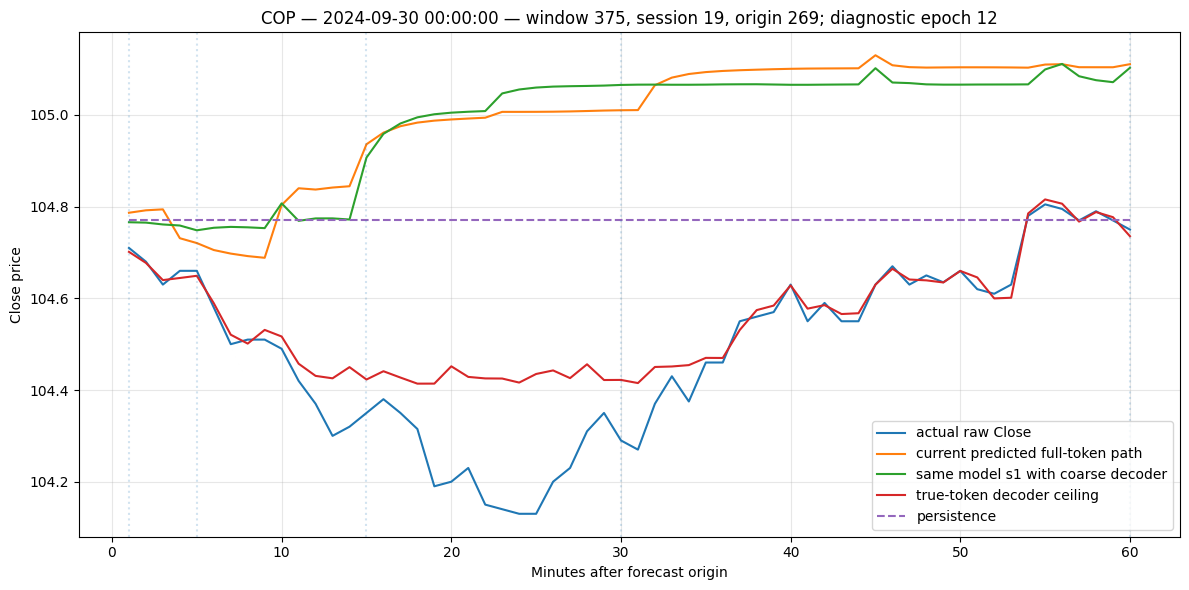

,window_index,asset_index,asset,date,sample_idx,origin_idx,origin_close,diagnostic_epoch,saved_vs_regenerated_eval_max_abs_difference
0,375,19,COP,2024-09-30 00:00:00,19,269,104.769997,12,NaN


In [46]:
# Cell 12 — draw a random current-run forecast path.

def plot_random_forecast_path() -> dict[str, Any]:
    random_generator = np.random.default_rng()
    window_index = int(random_generator.integers(0, len(validation_dataset)))
    asset_index = int(random_generator.integers(0, len(asset_cols)))

    batch = collate_cache_items(validation_dataset, [window_index])
    with torch.inference_mode():
        generated = diagnostic_model.generate(
            batch["context_tokens"].to(MODEL_DEVICE)
        )

    generated_tokens = generated.token_ids.detach().cpu().long()
    context_tokens_one = batch["context_tokens"][
        :, :, asset_index : asset_index + 1
    ].long()
    generated_tokens_one = generated_tokens[
        :, :, asset_index : asset_index + 1
    ]
    true_tokens_one = torch.stack(
        [
            batch["target_s1"][:, :, asset_index : asset_index + 1],
            batch["target_s2"][:, :, asset_index : asset_index + 1],
        ],
        dim=-1,
    ).long()

    mean_one = batch["context_mean"][:, asset_index : asset_index + 1]
    std_one = batch["context_std"][:, asset_index : asset_index + 1]

    predicted_full = tokenizer.decode_token_path(
        context_tokens_one,
        generated_tokens_one,
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )
    predicted_coarse = tokenizer.decode_coarse_token_path(
        context_tokens_one,
        generated_tokens_one[..., 0],
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )
    oracle_full = tokenizer.decode_token_path(
        context_tokens_one,
        true_tokens_one,
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )

    raw_context, raw_future = raw_ohlcv_for_window(
        window_index,
        asset_indices=[asset_index],
    )

    actual_close = raw_future[:, 0, 3].numpy()
    origin_close = float(raw_context[-1, 0, 3])
    predicted_full_close = predicted_full[0, :, 0, 3].cpu().numpy()
    predicted_coarse_close = predicted_coarse[0, :, 0, 3].cpu().numpy()
    oracle_close = oracle_full[0, :, 0, 3].cpu().numpy()

    future_minutes = np.arange(1, 61)
    plt.figure(figsize=(12, 6))
    plt.plot(future_minutes, actual_close, label="actual raw Close")
    plt.plot(
        future_minutes,
        predicted_full_close,
        label="current predicted full-token path",
    )
    plt.plot(
        future_minutes,
        predicted_coarse_close,
        label="same model s1 with coarse decoder",
    )
    plt.plot(
        future_minutes,
        oracle_close,
        label="true-token decoder ceiling",
    )
    plt.plot(
        future_minutes,
        np.full(60, origin_close),
        linestyle="--",
        label="persistence",
    )

    saved_difference = float("nan")
    if diagnostic_epoch == int(best_checkpoint["epoch"]):
        saved_eval_close = prediction_result["y_pred"][
            window_index, :, asset_index, 0
        ].cpu().numpy()
        plt.scatter(
            evaluation_horizons,
            saved_eval_close,
            marker="x",
            s=70,
            label="saved all-horizon-best forecasts",
        )
        saved_difference = float(
            np.max(
                np.abs(
                    saved_eval_close
                    - predicted_full_close[evaluation_indices]
                )
            )
        )

    for horizon in evaluation_horizons:
        plt.axvline(horizon, linestyle=":", alpha=0.2)

    sample_idx = int(validation_cache["sample_idx"][window_index])
    origin_idx = int(validation_cache["origin_idx"][window_index])
    date = validation_cache["dates"][window_index]

    plt.xlabel("Minutes after forecast origin")
    plt.ylabel("Close price")
    plt.title(
        f"{asset_cols[asset_index]} — {date} — window {window_index}, "
        f"session {sample_idx}, origin {origin_idx}; diagnostic epoch {diagnostic_epoch}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "window_index": window_index,
        "asset_index": asset_index,
        "asset": asset_cols[asset_index],
        "date": date,
        "sample_idx": sample_idx,
        "origin_idx": origin_idx,
        "origin_close": origin_close,
        "diagnostic_epoch": diagnostic_epoch,
        "saved_vs_regenerated_eval_max_abs_difference": saved_difference,
    }


random_forecast_details = plot_random_forecast_path()
display(pd.DataFrame([random_forecast_details]))

# Rerun this cell, or call plot_random_forecast_path(), for a new draw.

In [13]:
# Cell 13 — compact evidence table for the current-run decision.

best_graph_stats = graph_state_table.loc[
    graph_state_table["state"] == "best"
].iloc[0]
last_graph_stats = graph_state_table.loc[
    graph_state_table["state"] == "last"
].iloc[0]

current_short = short_candidate_table.loc[
    short_candidate_table["run"] == "full_predicted_s1"
].iloc[0]
true_short = short_candidate_table.loc[
    short_candidate_table["run"] == "full_true_s1"
].iloc[0]
coarse_short = short_candidate_table.loc[
    short_candidate_table["run"] == "coarse_only"
].iloc[0]

native_full_decoder_row = decoded_variant_table.loc[
    decoded_variant_table["variant"]
    == "predicted full tokens (native predicted-s1 conditioning)"
].iloc[0]
coarse_decoder_row = decoded_variant_table.loc[
    decoded_variant_table["variant"]
    == "predicted coarse-only decode (same model s1)"
].iloc[0]

horizon_token_rows = evaluation_token_table.set_index("future_step")

summary_table = pd.DataFrame(
    [
        {
            "question": "Does predicted-s1 full-token training beat the coarse-only incumbent at its own best short epoch?",
            "diagnostic": float(
                current_short["short_clg_mae"] / coarse_short["short_clg_mae"]
            ),
            "interpretation": "Ratio <1 favours current full predicted-s1 training.",
        },
        {
            "question": "Does predicted-s1 conditioning beat the original true-s1 full-token run at its own best short epoch?",
            "diagnostic": float(
                current_short["short_clg_mae"] / true_short["short_clg_mae"]
            ),
            "interpretation": "Ratio <1 favours predicted-s1 conditioning.",
        },
        {
            "question": "What is current h=1 s1 top-1 accuracy at the diagnostic checkpoint?",
            "diagnostic": float(horizon_token_rows.loc[1, "s1_top1"]),
            "interpretation": "Computed over the configured validation diagnostic windows.",
        },
        {
            "question": "What is current h=5 s1 top-1 accuracy at the diagnostic checkpoint?",
            "diagnostic": float(horizon_token_rows.loc[5, "s1_top1"]),
            "interpretation": "Computed over the configured validation diagnostic windows.",
        },
        {
            "question": "How much does true-s1 counterfactual conditioning change h=1 s2 accuracy?",
            "diagnostic": float(
                horizon_token_rows.loc[1, "s2_top1_counterfactual_true_s1"]
                - horizon_token_rows.loc[1, "s2_top1_native_predicted_s1"]
            ),
            "interpretation": "Positive means s1 errors still constrain the fine head at h=1.",
        },
        {
            "question": "How much does true-s1 counterfactual conditioning change h=5 s2 accuracy?",
            "diagnostic": float(
                horizon_token_rows.loc[5, "s2_top1_counterfactual_true_s1"]
                - horizon_token_rows.loc[5, "s2_top1_native_predicted_s1"]
            ),
            "interpretation": "Positive means s1 errors still constrain the fine head at h=5.",
        },
        {
            "question": "Does native full decoding beat coarse decoding for the same current s1 path on the fixed subset?",
            "diagnostic": float(
                native_full_decoder_row["short_clg_mae"]
                / coarse_decoder_row["short_clg_mae"]
            ),
            "interpretation": "Ratio <1 means the current predicted s2 stream adds short-horizon value.",
        },
        {
            "question": "What is the native-full minus coarse invalid-candle-rate difference on the subset?",
            "diagnostic": float(
                native_full_decoder_row["invalid_candle_rate_percent"]
                - coarse_decoder_row["invalid_candle_rate_percent"]
            ),
            "interpretation": "Positive means the current s2 stream creates more invalid candles.",
        },
        {
            "question": "Does s1 forecasting loss reach the graph logits?",
            "diagnostic": float(free_static_graph_gradient_rms),
            "interpretation": "Off-diagonal s1-loss gradient RMS at the diagnostic checkpoint.",
        },
        {
            "question": "How concentrated is the all-horizon-best graph?",
            "diagnostic": float(best_graph_stats["mean_effective_neighbours"]),
            "interpretation": "Uniform non-self graph is 92 effective neighbours.",
        },
        {
            "question": "How concentrated is the last graph?",
            "diagnostic": float(last_graph_stats["mean_effective_neighbours"]),
            "interpretation": "Shows whether concentration continued after the saved best epoch.",
        },
    ]
)

print("Short-horizon candidate ranking")
display(short_candidate_table)
print("Current-run decision evidence")
display(summary_table)
print(
    "This notebook does not replace the three earlier run-specific notebooks "
    "and writes no files."
)
print("FULL PREDICTED-S1 RUN DIAGNOSTIC NOTEBOOK COMPLETE")

Short-horizon candidate ranking


,run,selection,epoch,h1_clg_mae,h5_clg_mae,short_clg_mae,h15_clg_mae,h30_clg_mae,h60_clg_mae,all_horizon_score,validation_token_ce,validation_s1_ce,validation_s2_ce,generated_s1_accuracy,generated_s2_accuracy,invalid_dense_candle_rate_percent,graph_effective_neighbours
0,coarse_only,best_short,10,0.000468,0.000944,0.000706,0.001687,0.002393,0.003446,0.001788,4.519430,4.519430,0.000000,0.066816,NaN,24.112149,59.536568
1,full_predicted_s1,best_short,11,0.000481,0.000948,0.000715,0.001702,0.002397,0.003459,0.001797,7.880293,4.511539,3.368754,0.067146,0.175008,25.152990,83.273880
2,full_true_s1,best_short,10,0.000509,0.000990,0.000749,0.001739,0.002478,0.003585,0.001860,5.549958,4.552186,0.997771,0.066151,0.078530,38.813479,50.700603


Current-run decision evidence


,question,diagnostic,interpretation
0,Does predicted-s1 full-token training beat the...,1.012191,Ratio <1 favours current full predicted-s1 tra...
1,Does predicted-s1 conditioning beat the origin...,0.953749,Ratio <1 favours predicted-s1 conditioning.
2,What is current h=1 s1 top-1 accuracy at the d...,0.109677,Computed over the configured validation diagno...
3,What is current h=5 s1 top-1 accuracy at the d...,0.078268,Computed over the configured validation diagno...
4,How much does true-s1 counterfactual condition...,-0.000821,Positive means s1 errors still constrain the f...
5,How much does true-s1 counterfactual condition...,-0.000538,Positive means s1 errors still constrain the f...
6,Does native full decoding beat coarse decoding...,1.004514,Ratio <1 means the current predicted s2 stream...
7,What is the native-full minus coarse invalid-c...,0.711806,Positive means the current s2 stream creates m...
8,Does s1 forecasting loss reach the graph logits?,0.000012,Off-diagonal s1-loss gradient RMS at the diagn...
9,How concentrated is the all-horizon-best graph?,90.774238,Uniform non-self graph is 92 effective neighbo...


This notebook does not replace the three earlier run-specific notebooks and writes no files.
FULL PREDICTED-S1 RUN DIAGNOSTIC NOTEBOOK COMPLETE
